# Introducción

-Conceptos del aprendizaje supervisado y no supervisado

    Algoritmo
    La meta principal es poder generalizar el problema de manera lógica para poder predecir y tomar decisiones sin que estén explicitamente programadas.

    Se dividen en dos tipos, supervisados y no supervisados.

-Algoritmos supervisaods sew dividen en tres tipos:


*   Clasificación:
    
    Se dividen en tres subtipos: Binarios (resultado verdadero o falso), multiclase (sus resultados son 3 o más opciones), multicategorico (multilabel, consiste en que un mismo resultado puede pertenecer a 2 o más categorías).

    Tipos de algoritmos:

    1. Logistic​Re⁠gression: binario, resultado verdadero o falso.
    2. DecisionTree​Classifier: binario y multiclase.
    3. RandomForest​Classifier: Binario y multiclase; son un conjunto de árboles de desción.
    4. GBTClassifier: Similares al RandomForestClassifier; sin embargo, éste también puede ser usado cono uno de regresión.
    5. Multilayer​Per⁠ceptron Clas⁠sifier: Multiclase y se basa en redes neuronales. a diferencia de lso anteriores, éste espera contar con el tamaño de las capas de red neuronal, características de la data indexadas, y etiquetas indexadas.
    6. LinearSVC:SVC es para Super Vector machine Classifier, y es binario.
    7. OneVsRest: uno contra el resto, , binario o multiclase; espera contar con clasificación binaria, vectores, etquetas indizadas.
    8. NaiveBayes: es del tipo multiclase, eficiente para datos de entrenamiento; siempre espera un tipo de dato DOUBLE , en relación al peso de la data, para corregir el sesgo de la data.
    9. FMClassifier:Es binario.
    
    Nota1: cada uno de estos algoritmos esperean contar con vectores e indices en las características.

    Nopta2: Cuando se tiene clases imbalanceadas es importate considerar el sesgo de información, lo anterior debido a que aecta el resultado de salida. Para corregir el sesgo se debe tomar una más pequeña para balancer las clases.



*   Regresión

    Se dibviden en tres tipos: simple (sólo existe una variable independiente y otra dependiente), multiple ( una variable dependiente y dos o más independientes), y mutivariante (multiples variables dependiente e independientes).

    Comparten algoritmos con los de clasificación, eg. RandomForest, XGBoost, Regresión lineal, etc.
*   Recomendación
    
    Se divien en tres tipos: basados en contenido (content-based, con base en la metadata del usuario y del contenido, se analiza la inforamción para la obtención del resultado. No es ML necesariamente), filtrado colaborativo (solo utiliza las matrices de interacción), redes neuronales (utilizan la metadata y las matrices de interacción)


-Algoritmos no supervisados:

*  Frequent Pattern Mining
    
    Se basan en reglas de asociación libre para poder descubiri patrones entre diferentes variables. La regla que siguen es antecedente (if) y consequente (then), es decir acción-reacción.
*  Clustering
    
    Es una técnica basada en descubrir patrones en la información, como segmentación de clientes, procesamiento de imágenes, etc. Se basaan en tomar un punto central, y aparir de ahí conectar al punto que tenga la proximidad más pequeña y con las mismas características.

    Algunos algoritmos son:
    1. LDA (Latent Dirichlet Allocation): Se utliza en biomedicina, biología, entre otras.
    2. GaussianMixture: Se utiliza para saber cuánta precencia tiene un grupo dentro de uno más grande. No se recomienda cuando las columnas (variables) son mayores en relación a las filas/registros/tuplas.
    3. KMeans: Similar al KNN, crea varios puntos centrales dentro de los datos y empieza a elegi a sus vecinos más cercanos.
    4. BisectingKMeans: Basado en el KMeans, sólo que la distancia se mide por dos opciones la euclidiana o el cosiente. El modelo es similar al un árbol y sirve para visualizar de manera sencilla grupos y subgrupos.
    5. PowerIterationClustering (PCI): no me queda muy claro, pero se basa en el algritmo creado por Lun y Cohen.

    
-Algos diponibles en PySpark: Los algoritmos explicado en el capítulo de libro se encuentran disponibles en PySpark (https://spark.apache.org/docs/latest/ml-classification-regression.html).


# 2. Selección de datos

In [1]:
from pyspark.sql import SparkSession

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
spk= SparkSession.builder.appName('test').getOrCreate()
spk

In [3]:
df= spk.read.csv('/content/drive/MyDrive/Colab Notebooks/Big Data/KG_DATA/loan.csv', header=True, inferSchema=True)
df.show()

+----+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+----+----+------------------+--------------------+--------+----------+-----+-----------+----------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-------+-----------+-----------+----------+--------+----------------+------+-----------+------------

In [4]:
print(df.columns)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_i

In [5]:
columnas = [
    'out_prncp',#Remaining outstanding principal for total amount funded
    'loan_amnt',#The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
    'total_pymnt',#Payments received to date for total amount funded
    'open_acc',#The number of open credit lines in the borrower's credit file.
    'num_sats',#Number of satisfactory accounts
    'total_rec_prncp',#Principal received to date
    'num_rev_tl_bal_gt_0',#Number of revolving trades with balance >0
    'num_actv_rev_tl',#Number of currently active revolving trades
    'tot_hi_cred_lim',#Total high credit/credit limit
    'tot_cur_bal', #Total current balance of all accounts
    'last_pymnt_amnt',#Last total payment amount received
    'total_bal_il',#Total current balance of all installment accounts
    'total_il_high_credit_limit',#Total installment high credit/credit limit
    'installment',#The monthly payment owed by the borrower if the loan originates.
    'total_bal_ex_mort',#Total credit balance excluding mortgage
    'revol_util',#Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
    'bc_util', #Ratio of total current balance to high credit/credit limit for all bankcard accounts.
    'emp_length',
    'home_ownership',
    'grade',#Variable de salida no supervisadso
    'funded_amnt'#The total amount committed to that loan at that point in time. #VARIABLE DE SALIDA SUPERVISADO
]

dfML = df.select(columnas)

In [6]:
dfML.show()

+---------+---------+-----------+--------+--------+---------------+-------------------+---------------+---------------+-----------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+
|out_prncp|loan_amnt|total_pymnt|open_acc|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|emp_length|home_ownership|grade|funded_amnt|
+---------+---------+-----------+--------+--------+---------------+-------------------+---------------+---------------+-----------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+----------+--------------+-----+-----------+
|  2386.02|     2500|     167.02|       9|       9|         113.98|                  5|              5|          60124|      16901|          84.92|       125

In [7]:
dfML.dtypes

[('out_prncp', 'string'),
 ('loan_amnt', 'int'),
 ('total_pymnt', 'string'),
 ('open_acc', 'string'),
 ('num_sats', 'int'),
 ('total_rec_prncp', 'string'),
 ('num_rev_tl_bal_gt_0', 'int'),
 ('num_actv_rev_tl', 'int'),
 ('tot_hi_cred_lim', 'int'),
 ('tot_cur_bal', 'string'),
 ('last_pymnt_amnt', 'string'),
 ('total_bal_il', 'string'),
 ('total_il_high_credit_limit', 'int'),
 ('installment', 'double'),
 ('total_bal_ex_mort', 'int'),
 ('revol_util', 'string'),
 ('bc_util', 'string'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('grade', 'string'),
 ('funded_amnt', 'int')]

In [8]:
from pyspark.sql.functions import regexp_replace, col
#sintaxis casteo
#   'cast (loan_amnt as double) loan_amnt',

columns_cast = [
'cast (out_prncp as double) out_prncp',
'cast (loan_amnt as double) loan_amnt',
'cast (total_pymnt as double) total_pymnt',
'cast (num_sats as int) num_sats',
'cast (total_rec_prncp as double) total_rec_prncp',
'cast (num_rev_tl_bal_gt_0 as int) num_rev_tl_bal_gt_0',
'cast (num_actv_rev_tl as int) num_actv_rev_tl',
'cast (tot_hi_cred_lim as double)  tot_hi_cred_lim',
'cast (tot_cur_bal as double)tot_cur_bal',
'cast (open_acc as int) open_acc',
'cast (last_pymnt_amnt as double) last_pymnt_amnt',
'cast (total_bal_il as double) total_bal_il',
'cast (total_il_high_credit_limit as double) total_il_high_credit_limit',
'cast (installment as double) installment',
'cast (total_bal_ex_mort as double) total_bal_ex_mort',
'cast (revol_util as double) revol_util',
'cast (bc_util as double) bc_util',
'cast (emp_length as string) emp_length',
'cast (home_ownership as string) home_ownership',
'cast (grade as string) grade',
'cast (funded_amnt as int) funded_amnt'
]

# Aplicamos la conversión sobre todo el DataFrame
dfML = dfML.selectExpr(*columns_cast)

# Mostrar el resultado
dfML.dtypes

[('out_prncp', 'double'),
 ('loan_amnt', 'double'),
 ('total_pymnt', 'double'),
 ('num_sats', 'int'),
 ('total_rec_prncp', 'double'),
 ('num_rev_tl_bal_gt_0', 'int'),
 ('num_actv_rev_tl', 'int'),
 ('tot_hi_cred_lim', 'double'),
 ('tot_cur_bal', 'double'),
 ('open_acc', 'int'),
 ('last_pymnt_amnt', 'double'),
 ('total_bal_il', 'double'),
 ('total_il_high_credit_limit', 'double'),
 ('installment', 'double'),
 ('total_bal_ex_mort', 'double'),
 ('revol_util', 'double'),
 ('bc_util', 'double'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('grade', 'string'),
 ('funded_amnt', 'int')]

In [9]:
dfML.describe().show()

+-------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+--------------------------+------------------+-----------------+-----------------+-----------------+----------+--------------+-------+------------------+
|summary|         out_prncp|         loan_amnt|       total_pymnt|          num_sats|  total_rec_prncp|num_rev_tl_bal_gt_0|   num_actv_rev_tl|   tot_hi_cred_lim|       tot_cur_bal|          open_acc|   last_pymnt_amnt|     total_bal_il|total_il_high_credit_limit|       installment|total_bal_ex_mort|       revol_util|          bc_util|emp_length|home_ownership|  grade|       funded_amnt|
+-------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+------------------+------------------+------------------+--

In [10]:
dfML.groupBy('grade').count().show()

+-----+------+
|grade| count|
+-----+------+
|    F| 41800|
|    E|135639|
|    B|663557|
|    D|324424|
|    C|650053|
|    A|433027|
|    G| 12168|
+-----+------+



In [11]:
dfML.groupBy('home_ownership').count().show()

+--------------+-------+
|home_ownership|  count|
+--------------+-------+
|           OWN| 253057|
|          RENT| 894929|
|      MORTGAGE|1111449|
|           ANY|    996|
|       2 years|      1|
|          NONE|     54|
|         OTHER|    182|
+--------------+-------+



In [12]:
dfML.groupBy('emp_length').count().show()

+----------+------+
|emp_length| count|
+----------+------+
|   9 years| 79395|
|   5 years|139698|
|    1 year|148403|
|       n/a|146907|
|   2 years|203676|
|   7 years| 92695|
|   8 years| 91914|
|   4 years|136605|
|   6 years|102628|
|   3 years|180753|
| 10+ years|748005|
|  < 1 year|189988|
| reactors"|     1|
+----------+------+



In [13]:
from pyspark.sql.functions import col

print('REGISTROS NULOS POR CAMPO ANTES DE IMPUTAR')
for column in dfML.columns:
    print(f'{column}: {dfML.filter(col(column).isNull()).count()}')

REGISTROS NULOS POR CAMPO ANTES DE IMPUTAR
out_prncp: 97
loan_amnt: 0
total_pymnt: 69
num_sats: 58588
total_rec_prncp: 33
num_rev_tl_bal_gt_0: 70274
num_actv_rev_tl: 70274
tot_hi_cred_lim: 70179
tot_cur_bal: 70196
open_acc: 196
last_pymnt_amnt: 71
total_bal_il: 866109
total_il_high_credit_limit: 70238
installment: 0
total_bal_ex_mort: 49948
revol_util: 1877
bc_util: 76071
emp_length: 0
home_ownership: 0
grade: 0
funded_amnt: 0


# 3. Preparación de los datos



In [14]:
import pandas as pd
import numpy as np

In [15]:
df_pd= dfML.limit(2000000).toPandas()

In [16]:
num_cols = df_pd.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_pd.select_dtypes(exclude=np.number).columns.tolist()

In [17]:
df_pd[num_cols].isnull().sum()

,0
out_prncp,1
loan_amnt,0
total_pymnt,1
num_sats,16055
total_rec_prncp,0
num_rev_tl_bal_gt_0,27741
num_actv_rev_tl,27742
tot_hi_cred_lim,27741
tot_cur_bal,27742
open_acc,0


In [18]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for num_sats:


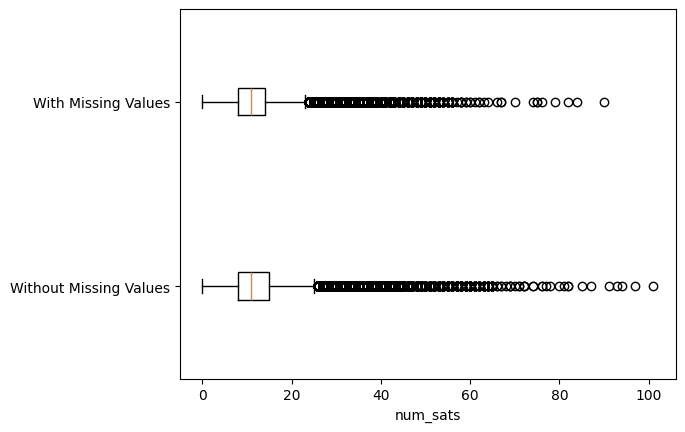

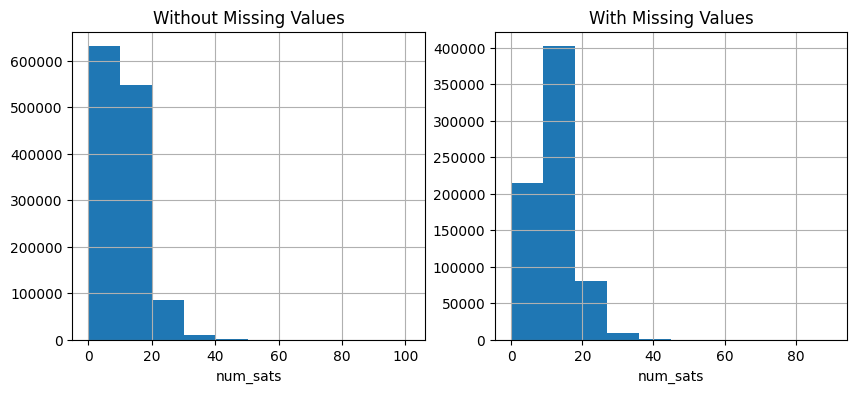

p-value of t-test: 0.9684695904129681
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for loan_amnt:


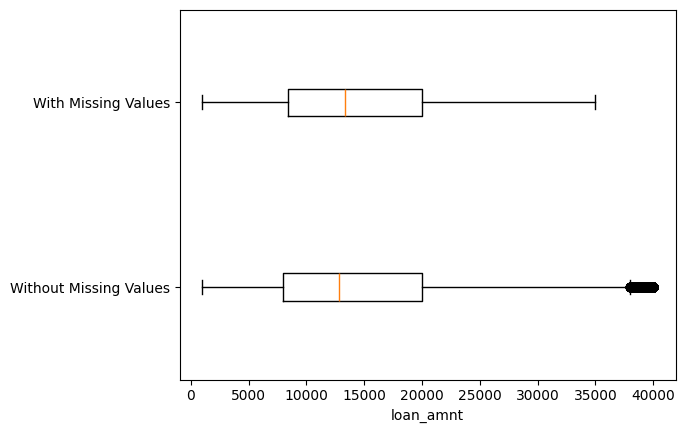

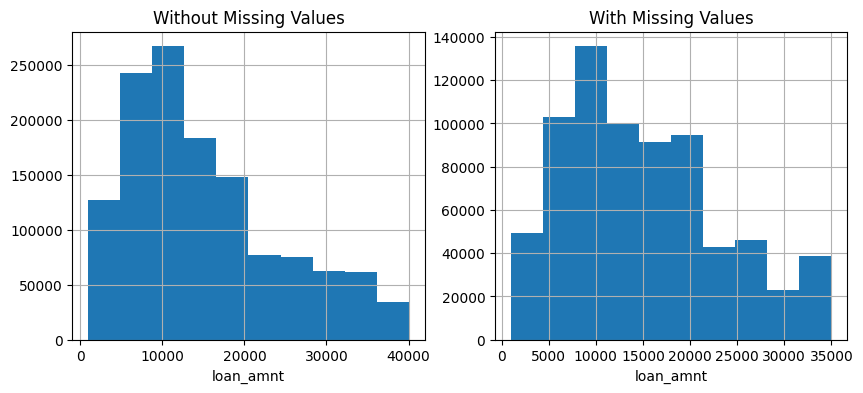

p-value of t-test: 2.2206548631370828e-92
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_pymnt:


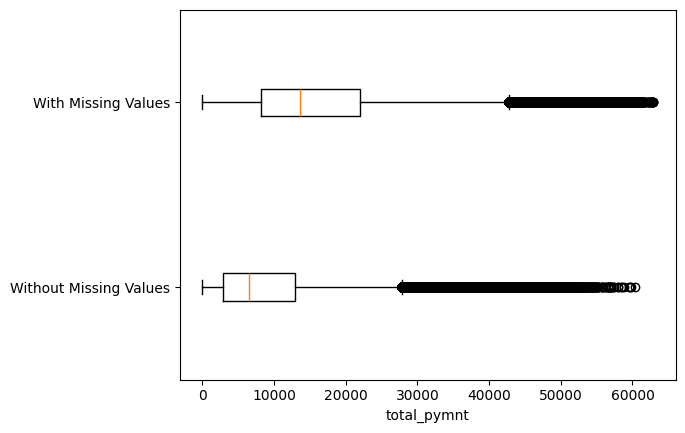

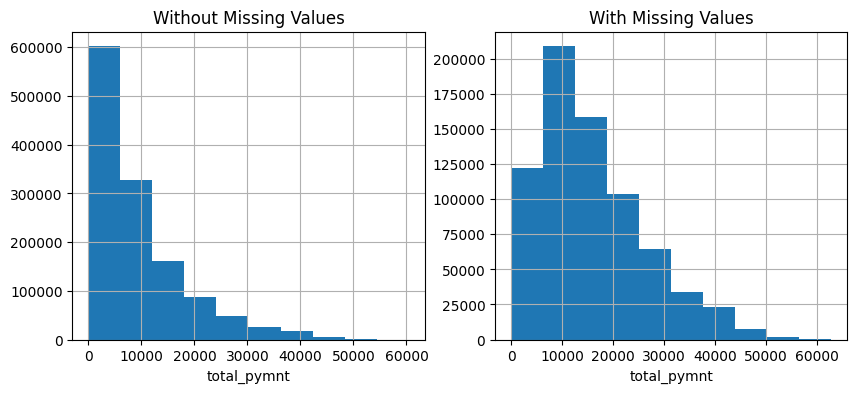

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_sats:


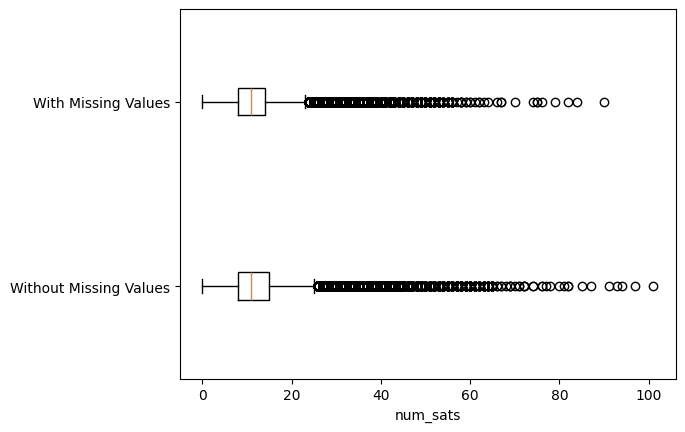

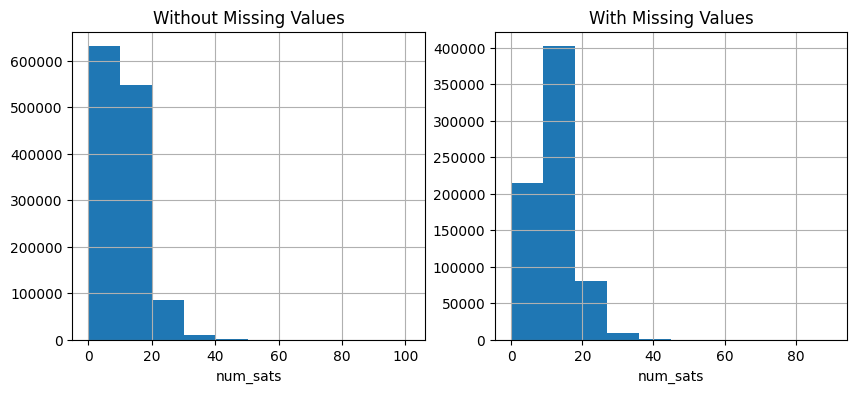

p-value of t-test: 0.9684695904129681
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_rec_prncp:


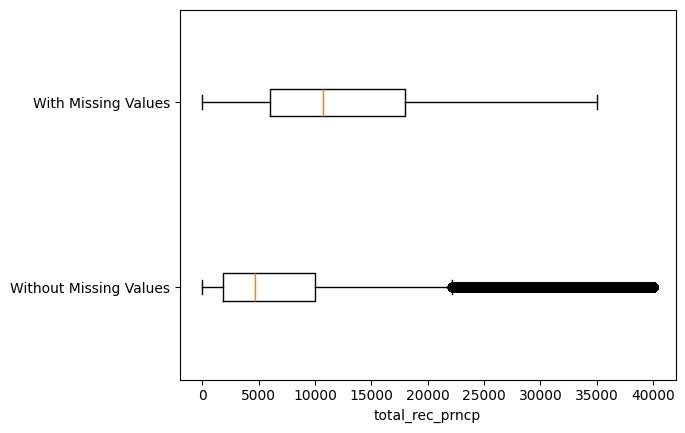

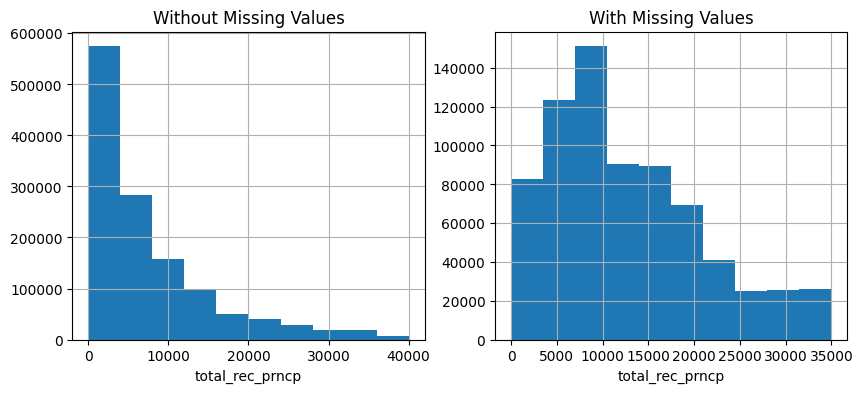

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_rev_tl_bal_gt_0:


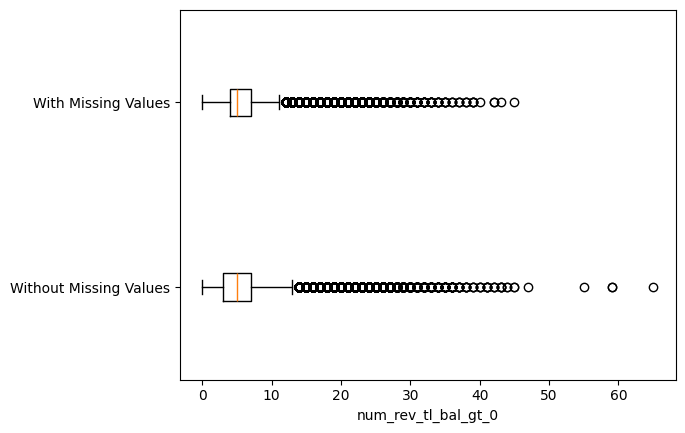

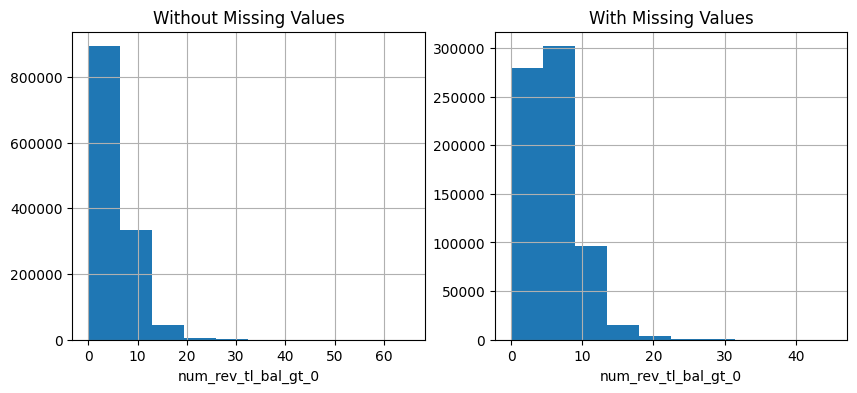

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_hi_cred_lim:


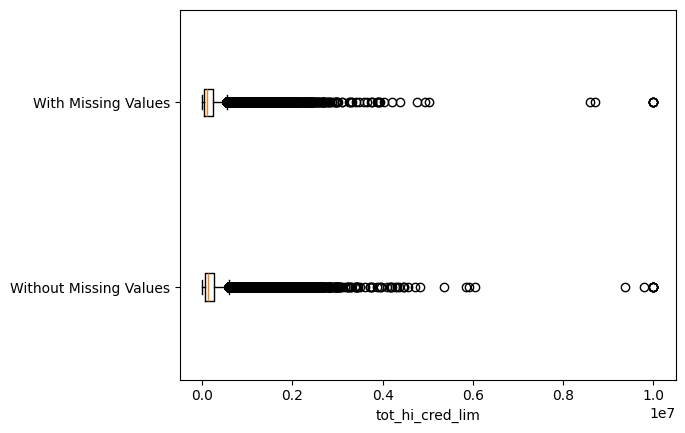

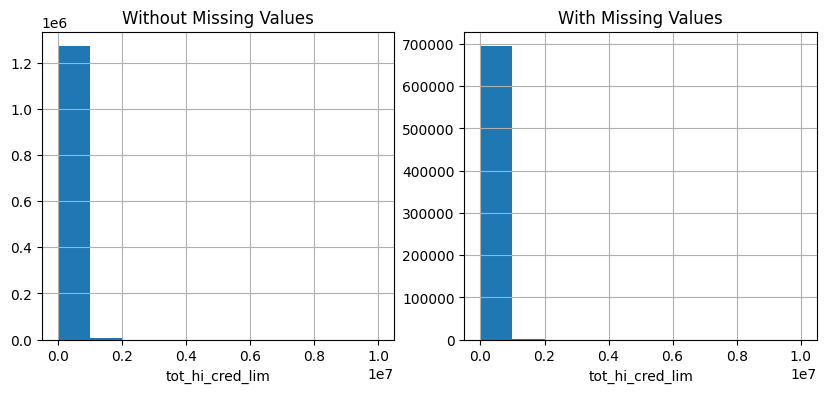

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_cur_bal:


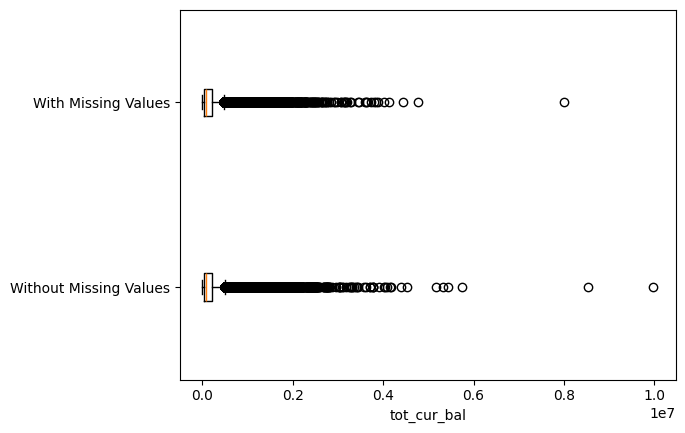

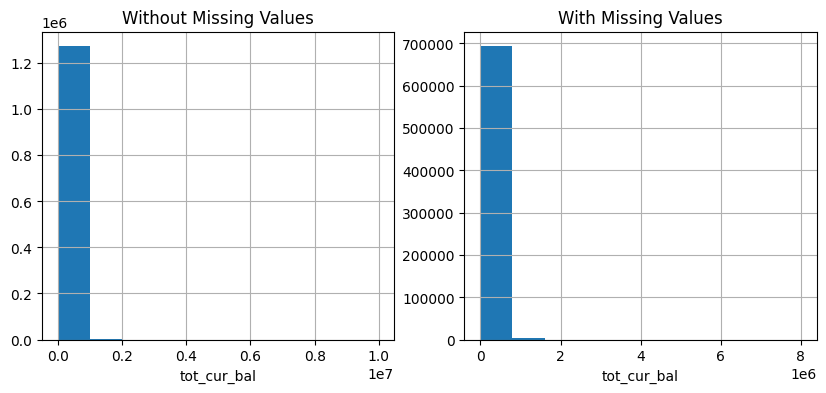

p-value of t-test: 7.547595930079073e-97
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for open_acc:


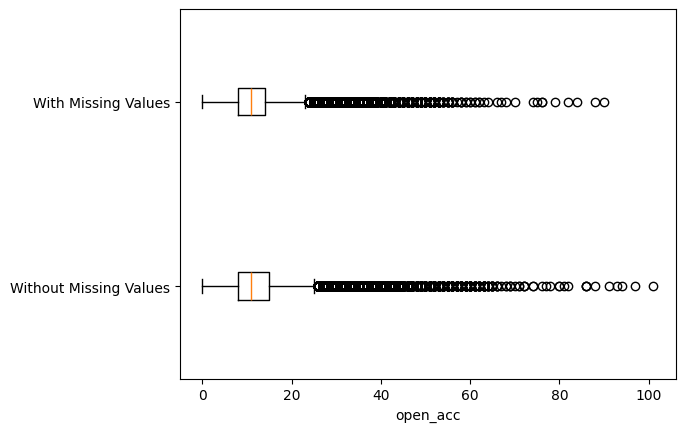

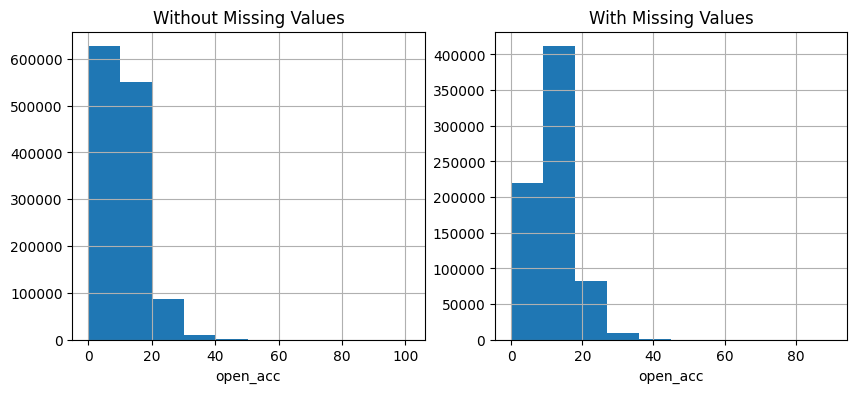

p-value of t-test: 3.3895803901540056e-05
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for last_pymnt_amnt:


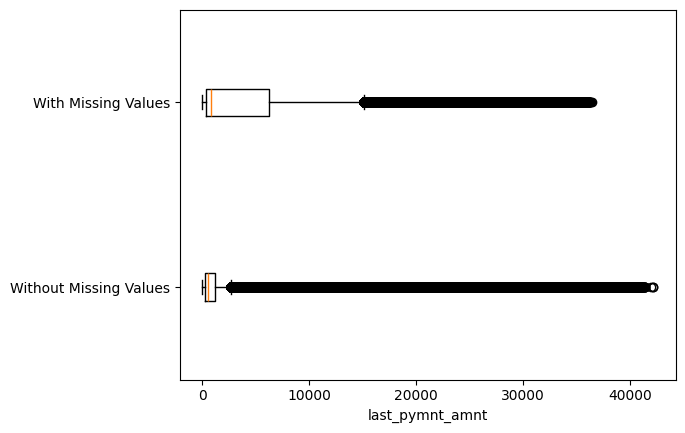

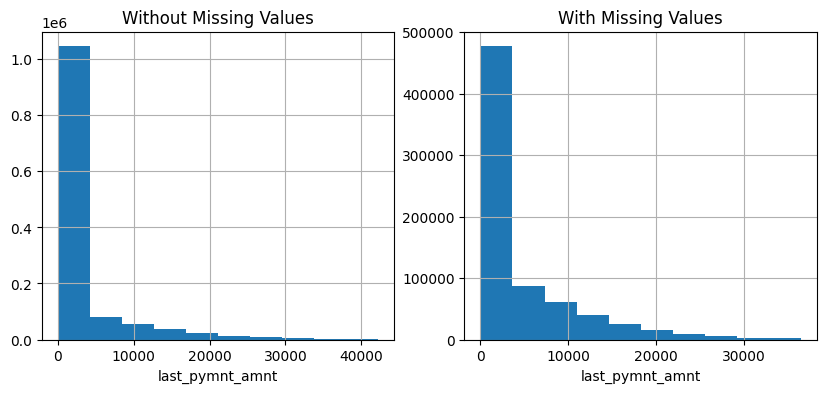

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_actv_rev_tl:


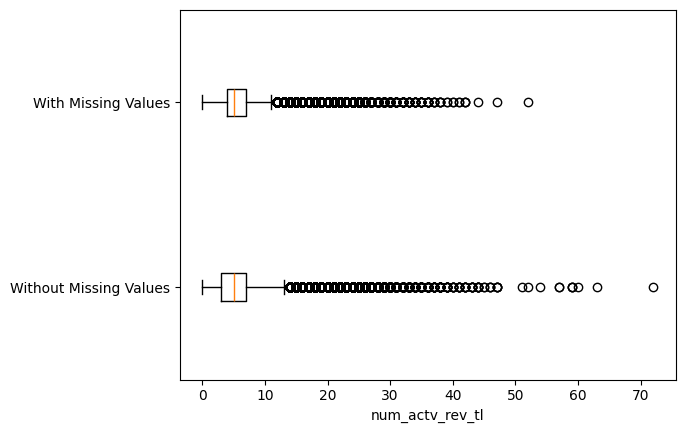

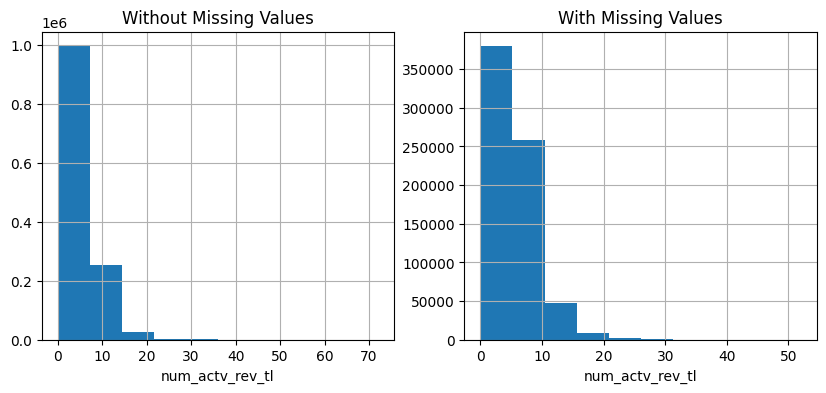

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_il_high_credit_limit:


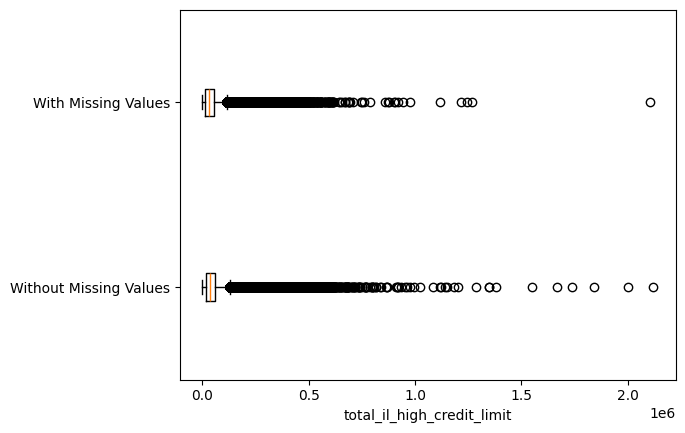

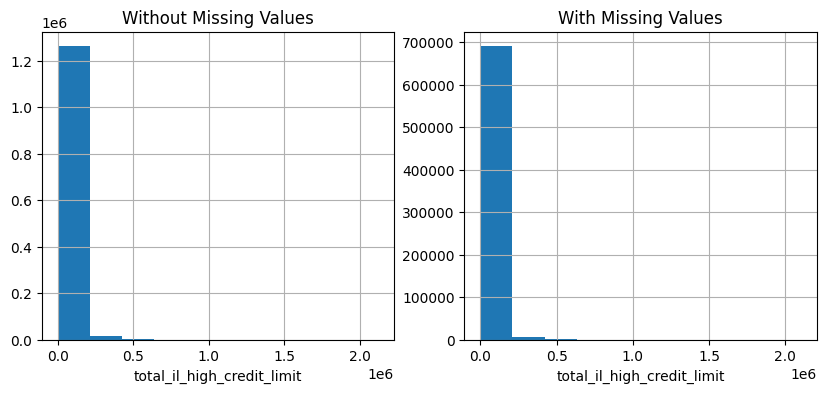

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for installment:


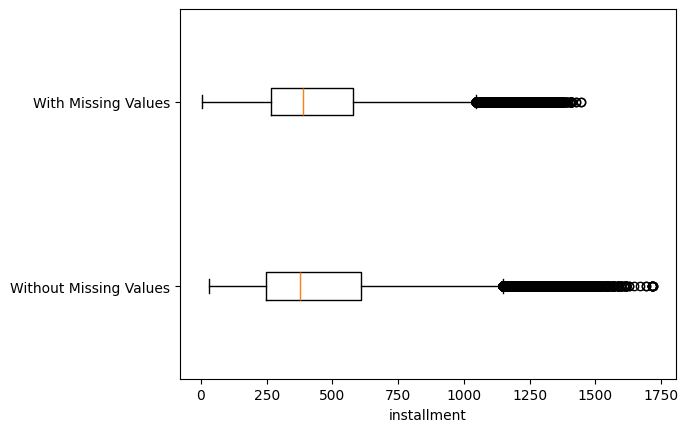

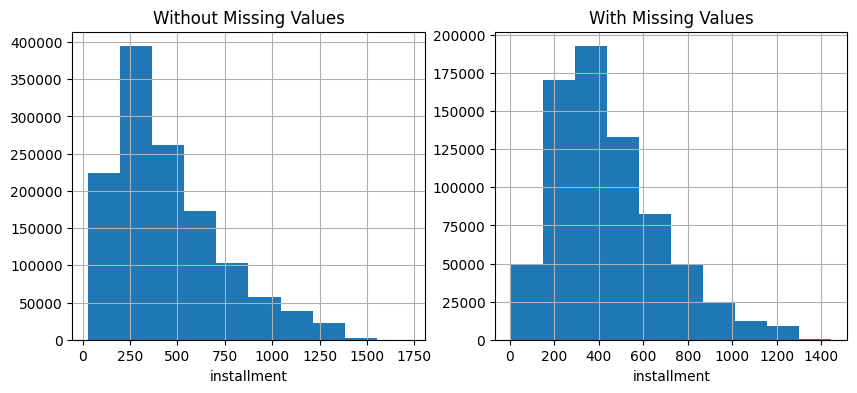

p-value of t-test: 1.3642894580080833e-141
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_bal_ex_mort:


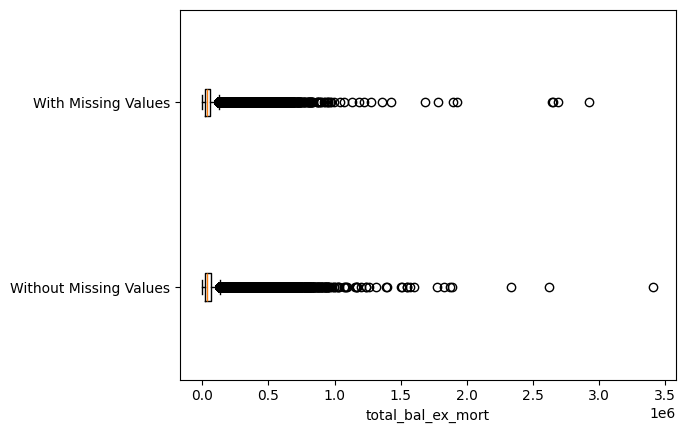

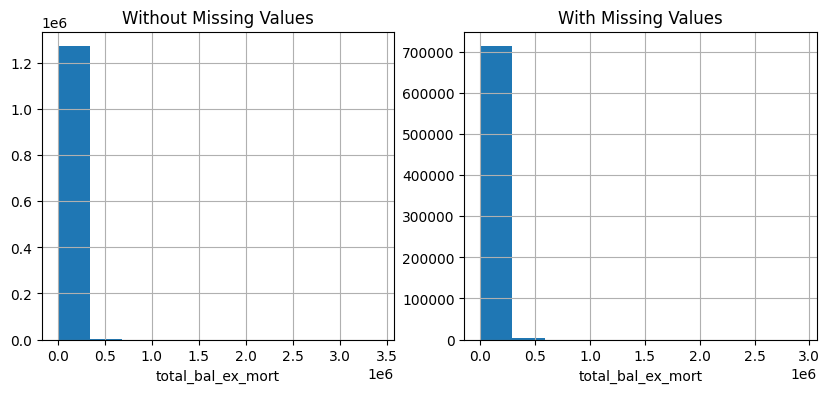

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for revol_util:


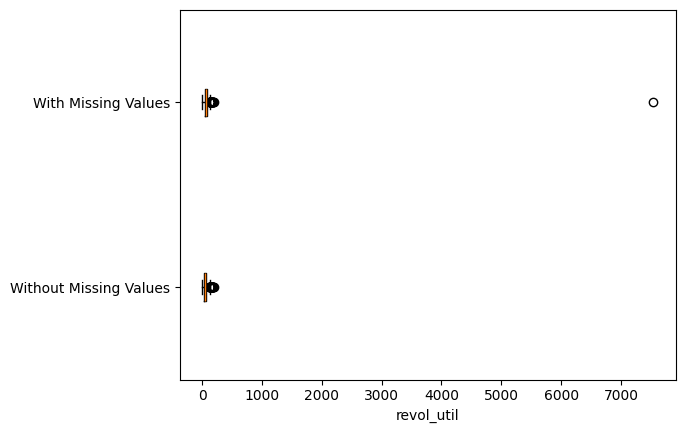

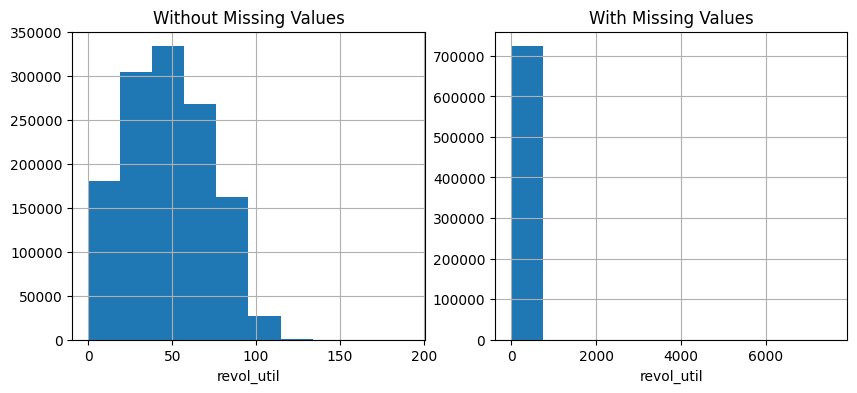

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for bc_util:


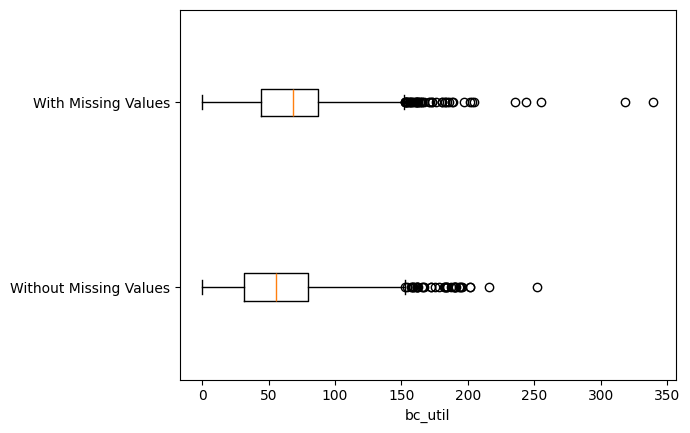

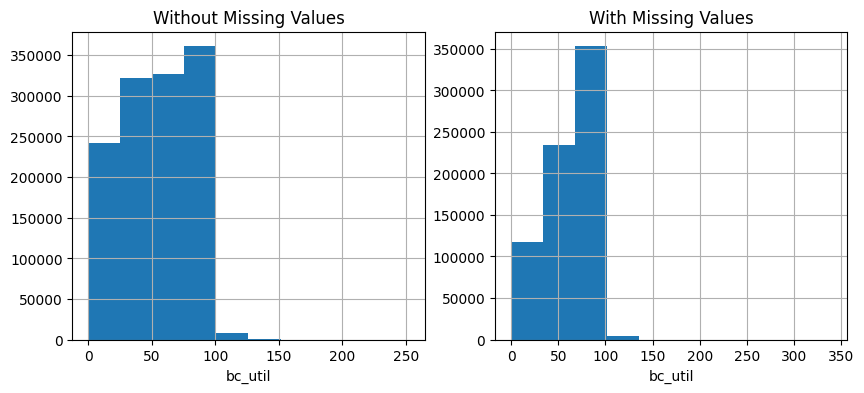

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 


In [19]:
numerical_attributes = ['num_sats','loan_amnt','total_pymnt','num_sats','total_rec_prncp','num_rev_tl_bal_gt_0','tot_hi_cred_lim','tot_cur_bal','open_acc','last_pymnt_amnt','num_actv_rev_tl','total_il_high_credit_limit','installment','total_bal_ex_mort','revol_util','bc_util']

BM_MV = df_pd['total_bal_il'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(df_pd,att,BM_MV)
    print('- - - - - - - - - - - - divider - - - - - - - - - - - ')

Diagnosis Analysis of Missing Values for total_bal_il:


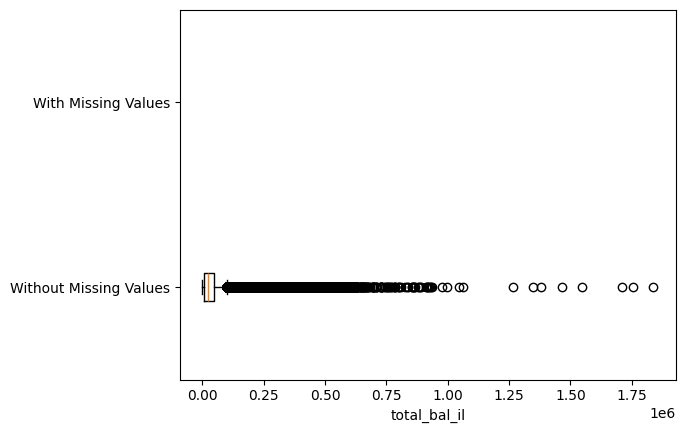

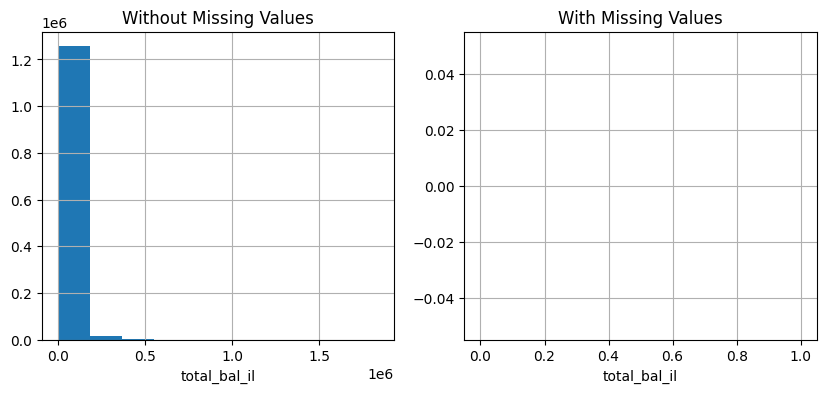

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for loan_amnt:


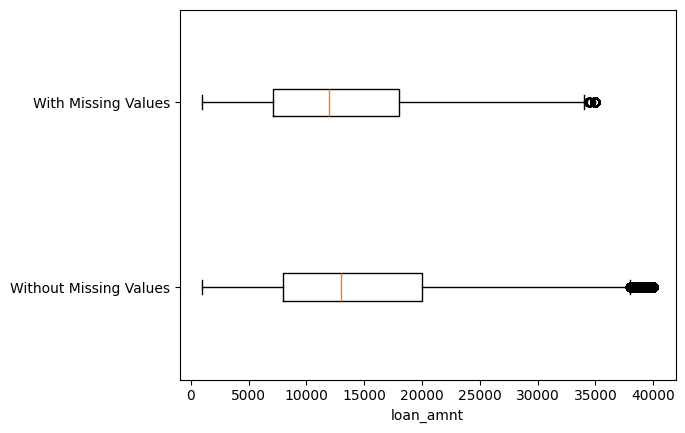

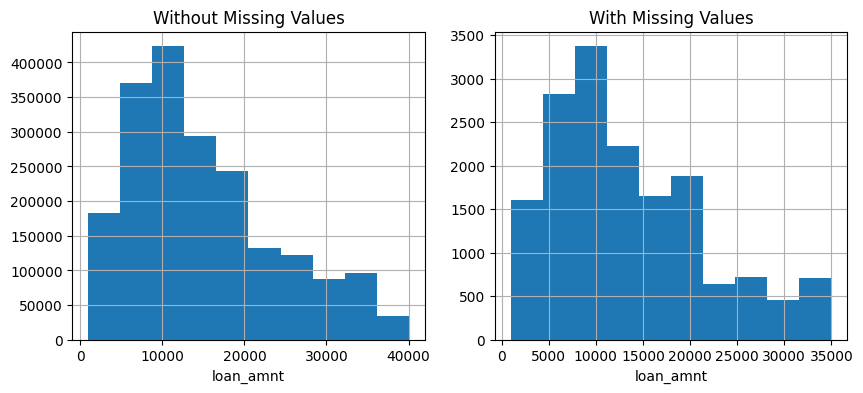

p-value of t-test: 1.685133779909517e-121
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_pymnt:


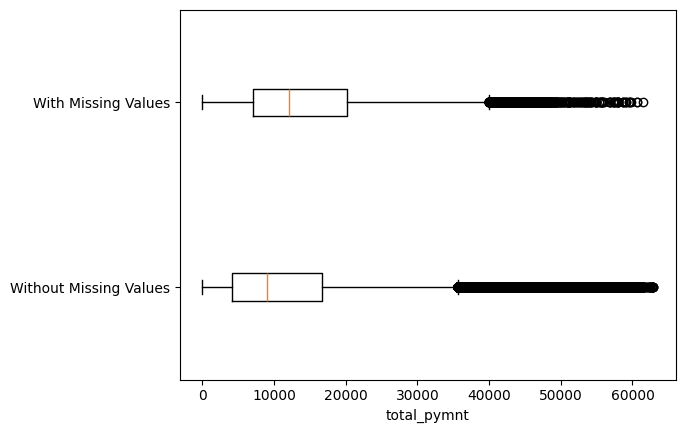

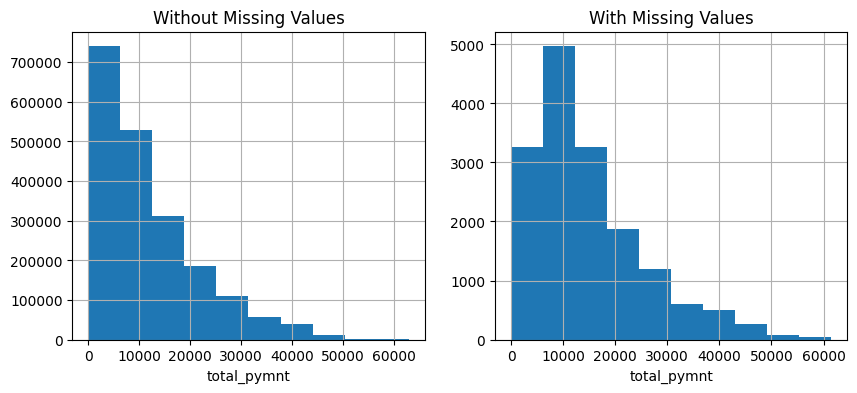

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_sats:


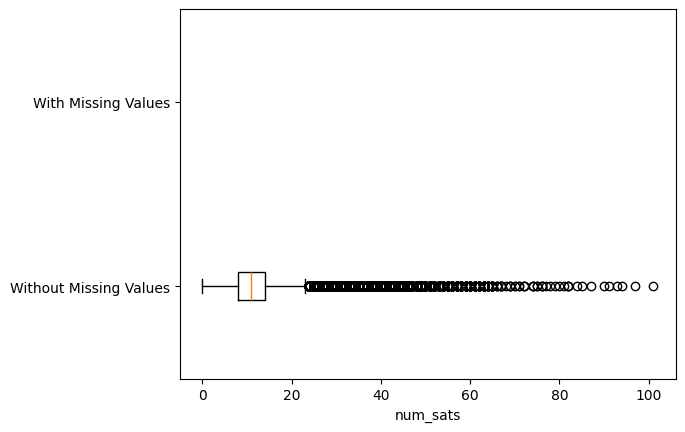

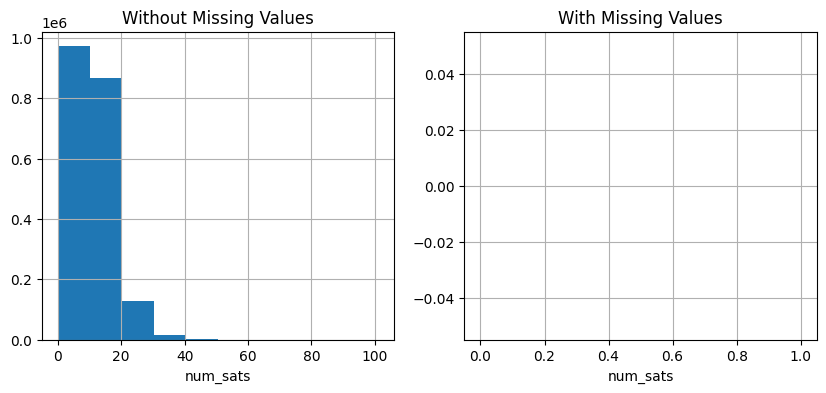

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_rec_prncp:


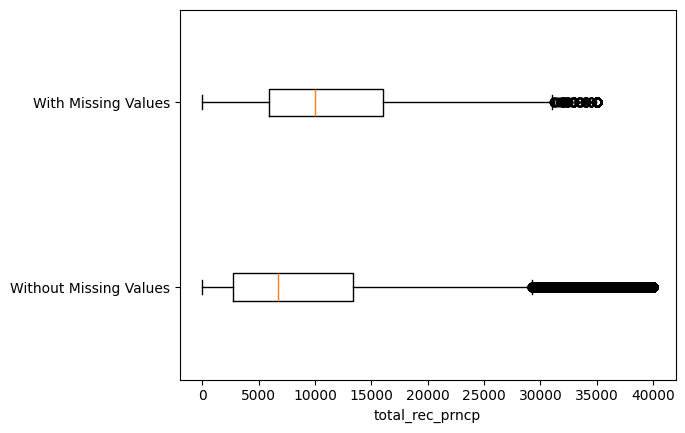

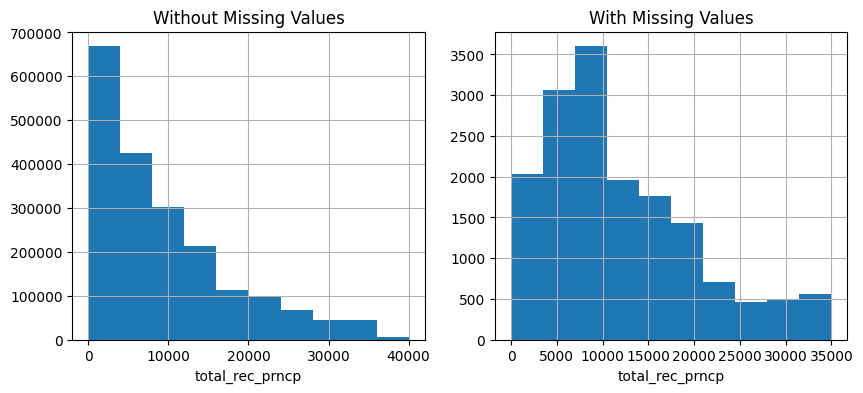

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_rev_tl_bal_gt_0:


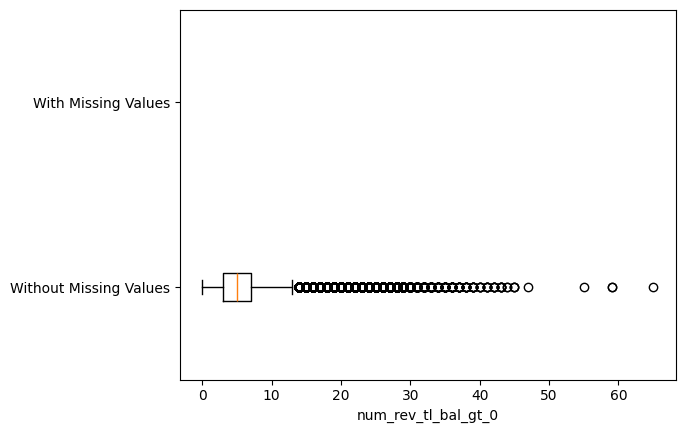

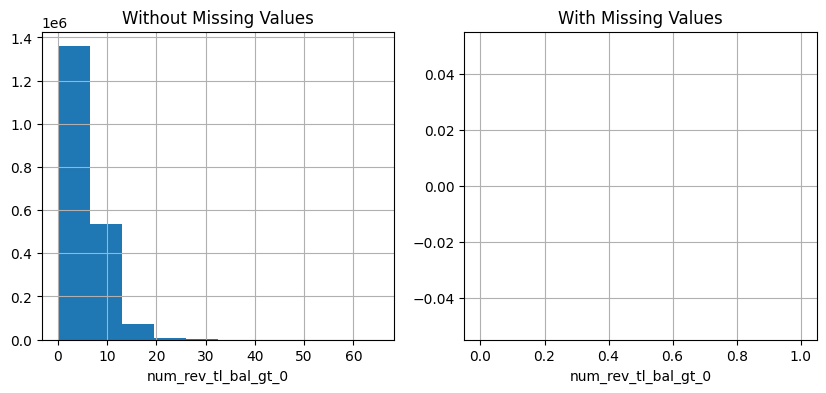

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_hi_cred_lim:


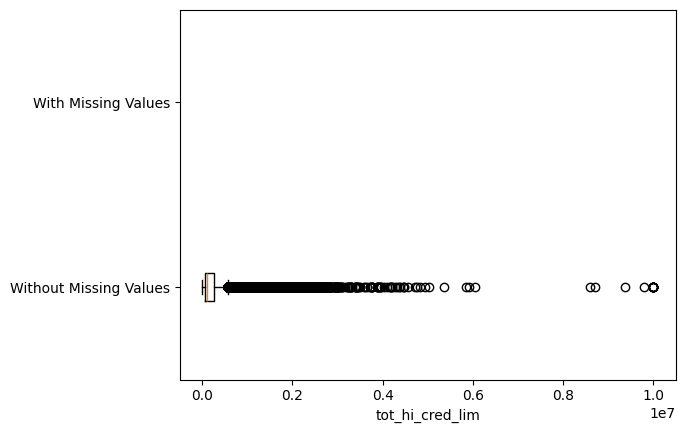

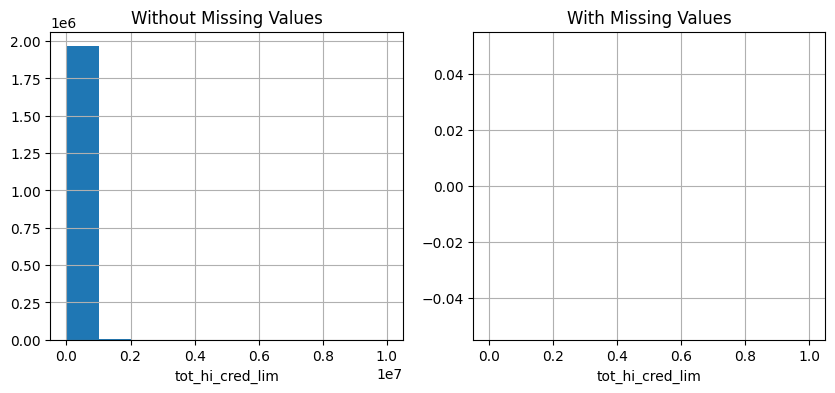

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_cur_bal:


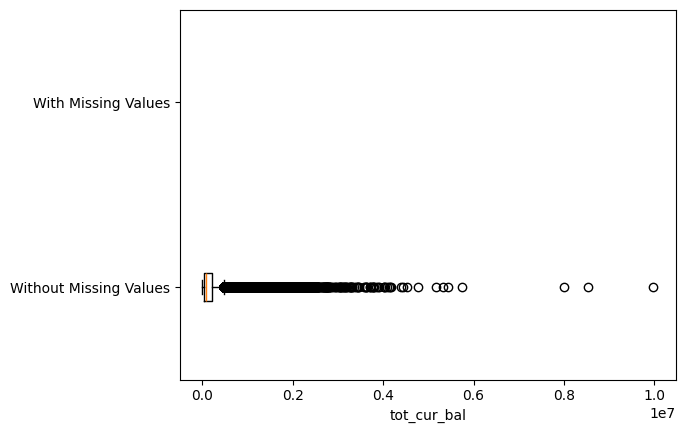

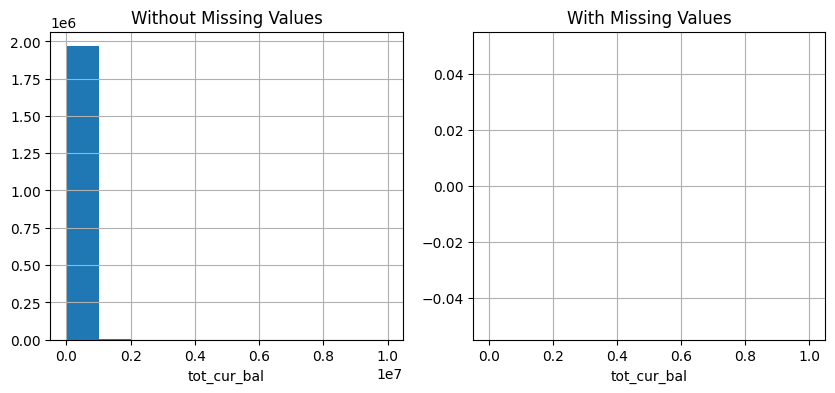

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for open_acc:


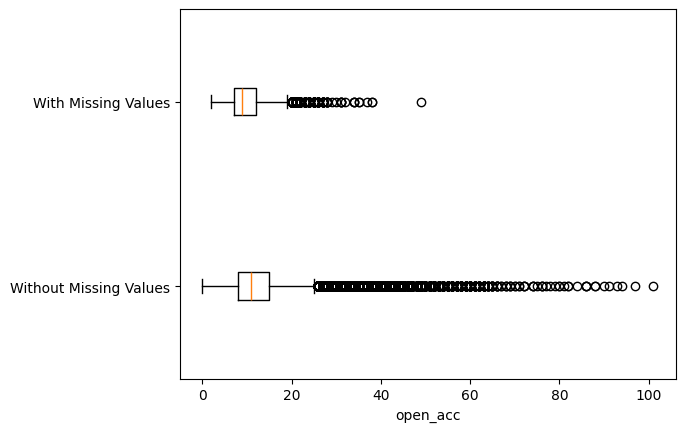

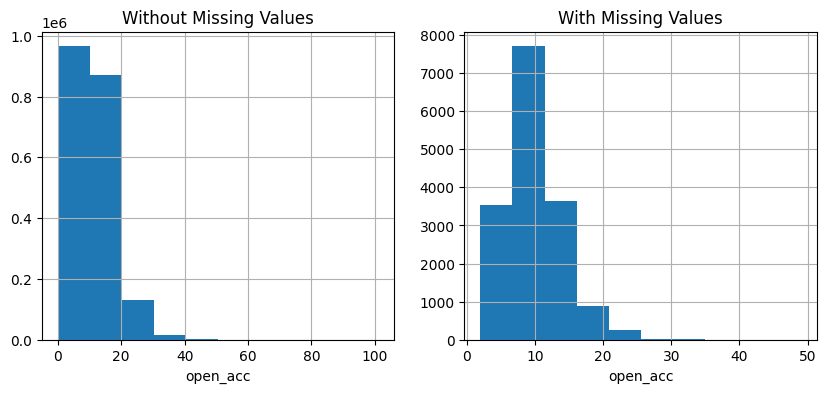

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for last_pymnt_amnt:


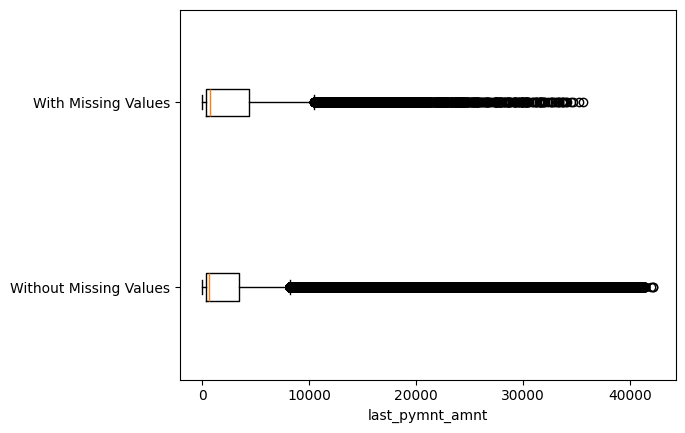

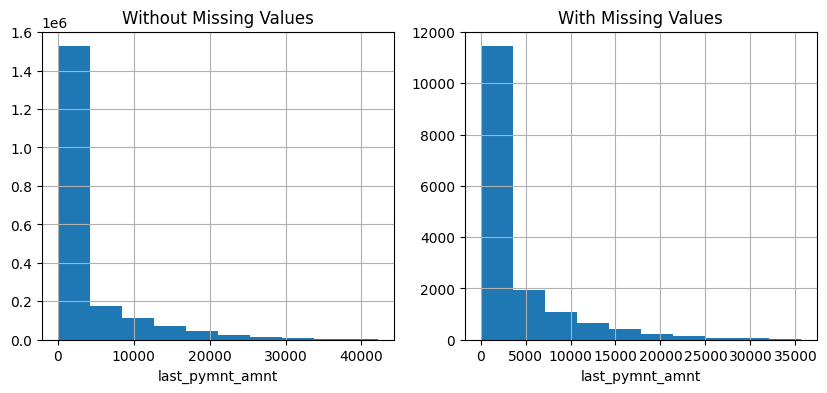

p-value of t-test: 0.19661175403597153
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_actv_rev_tl:


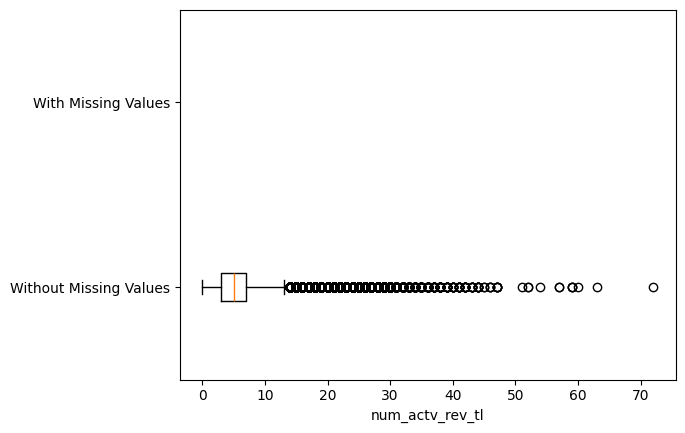

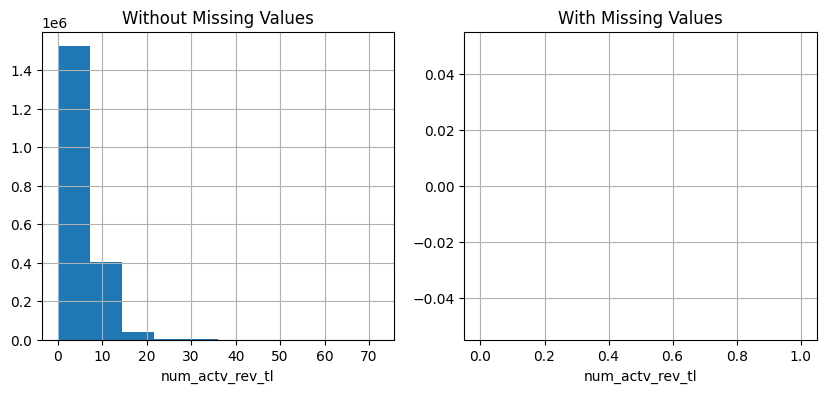

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_il_high_credit_limit:


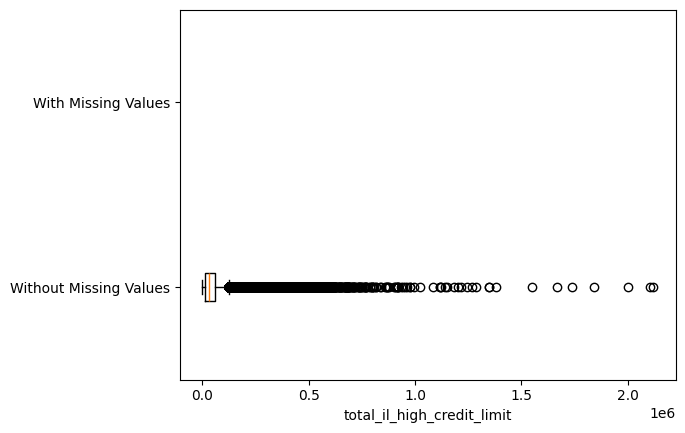

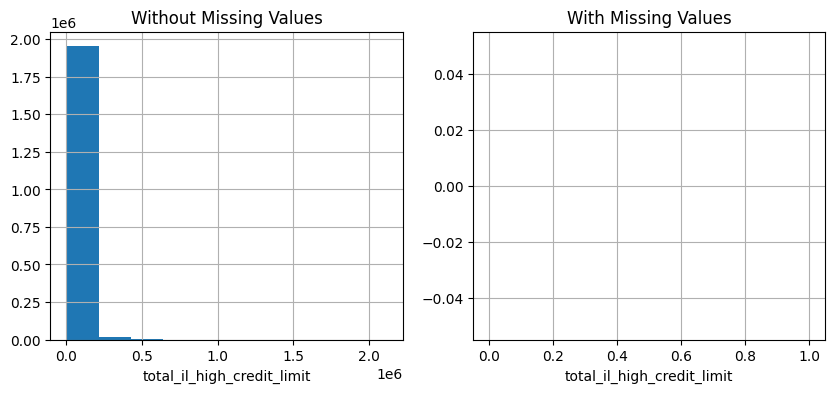

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for installment:


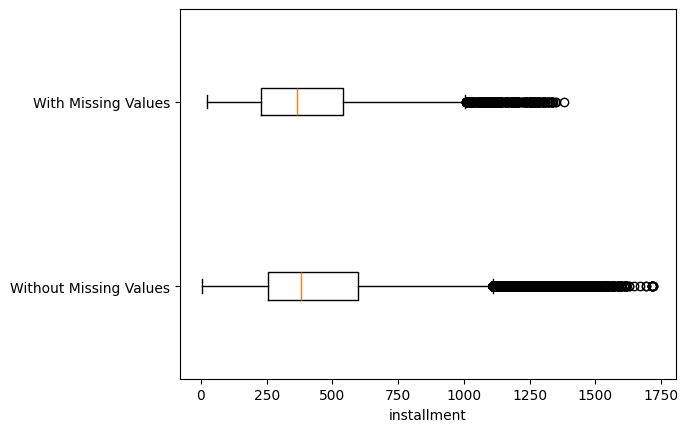

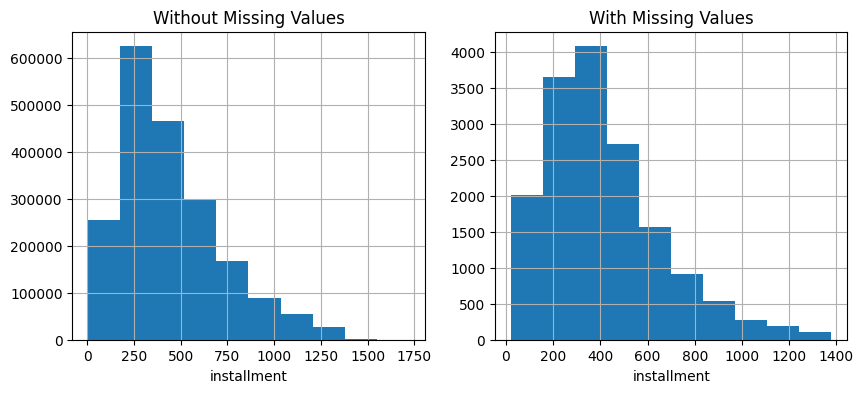

p-value of t-test: 1.7554472174241402e-58
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_bal_ex_mort:


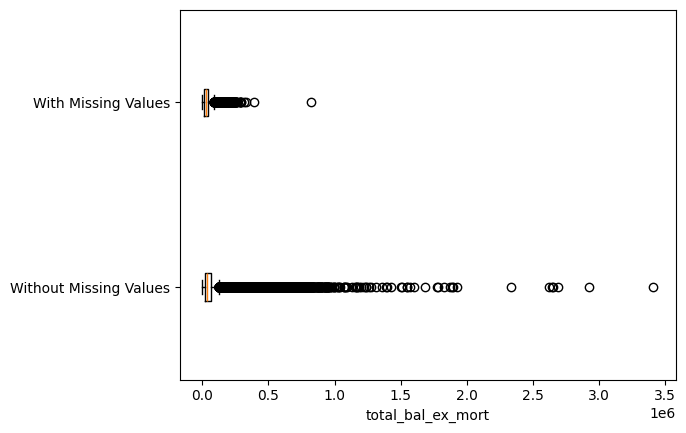

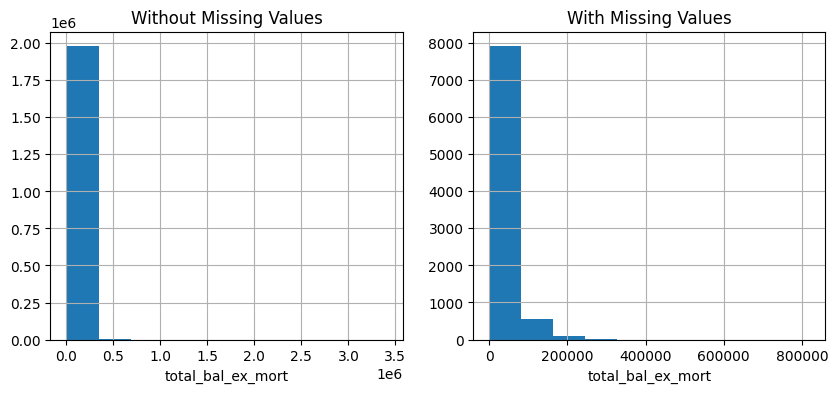

p-value of t-test: 4.1841788745008926e-175
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for revol_util:


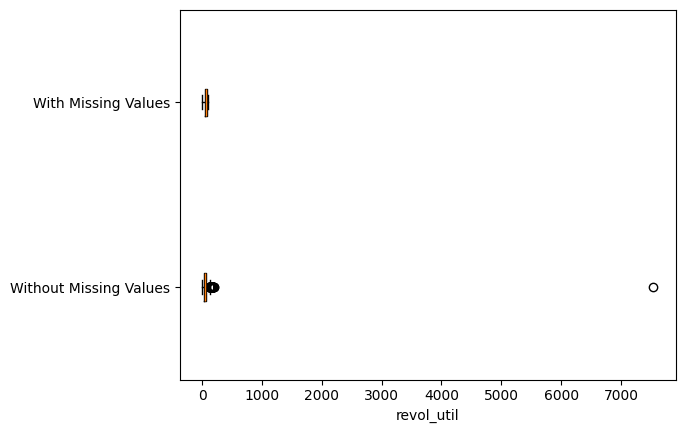

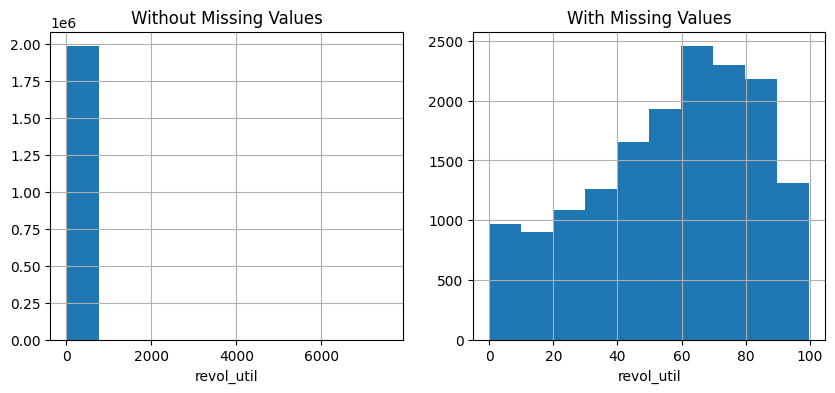

p-value of t-test: 5.316363498537042e-216
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for bc_util:


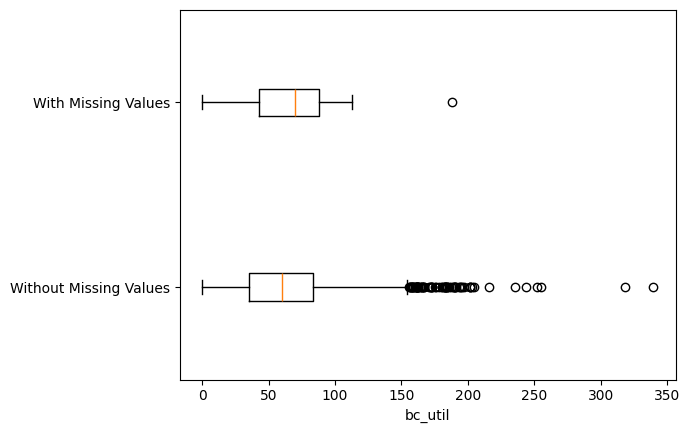

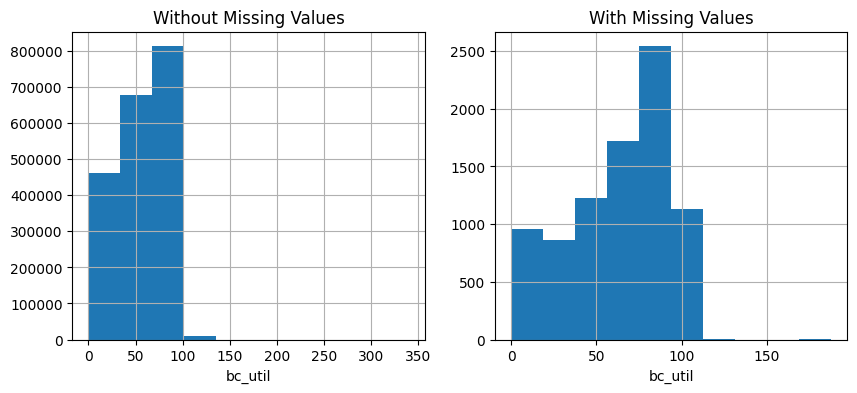

p-value of t-test: 1.3424107796965133e-58
- - - - - - - - - - - - divider - - - - - - - - - - - 


In [20]:
numerical_attributes = ['total_bal_il','loan_amnt','total_pymnt','num_sats','total_rec_prncp','num_rev_tl_bal_gt_0','tot_hi_cred_lim','tot_cur_bal','open_acc','last_pymnt_amnt','num_actv_rev_tl','total_il_high_credit_limit','installment','total_bal_ex_mort','revol_util','bc_util']

BM_MV = df_pd['num_sats'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(df_pd,att,BM_MV)
    print('- - - - - - - - - - - - divider - - - - - - - - - - - ')

Diagnosis Analysis of Missing Values for num_sats:


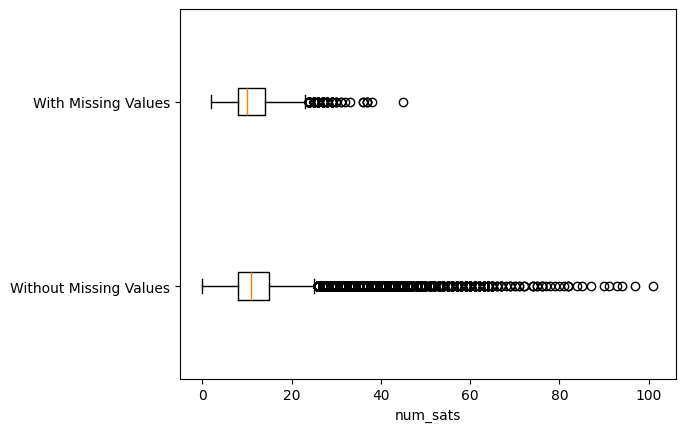

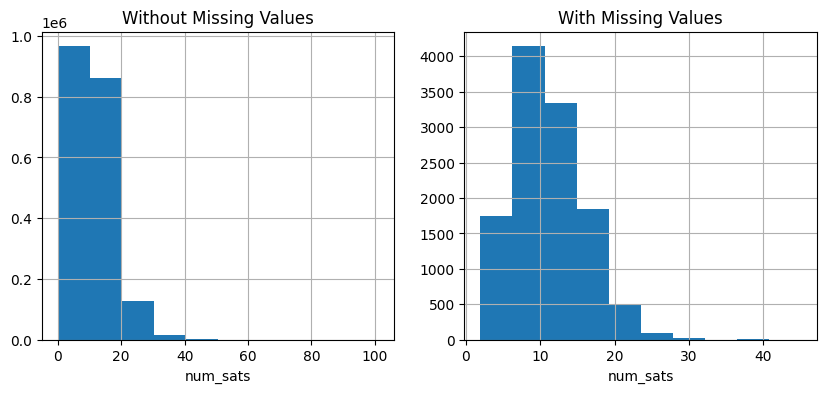

p-value of t-test: 8.492030441144883e-27
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for loan_amnt:


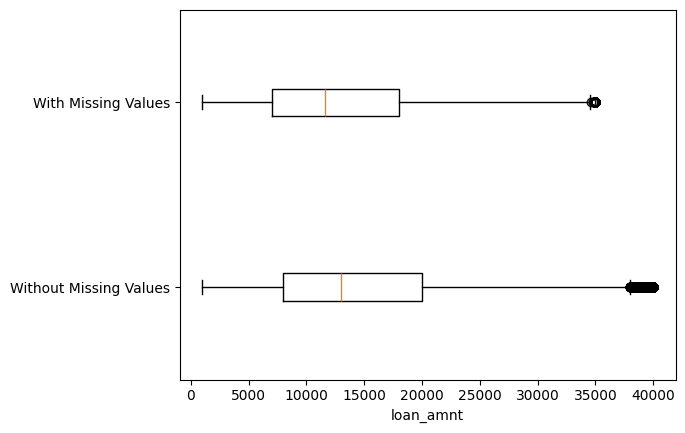

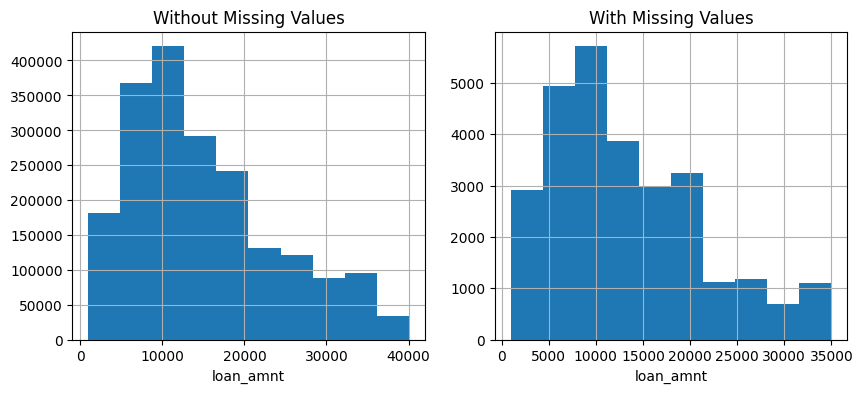

p-value of t-test: 3.775128546241768e-262
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_pymnt:


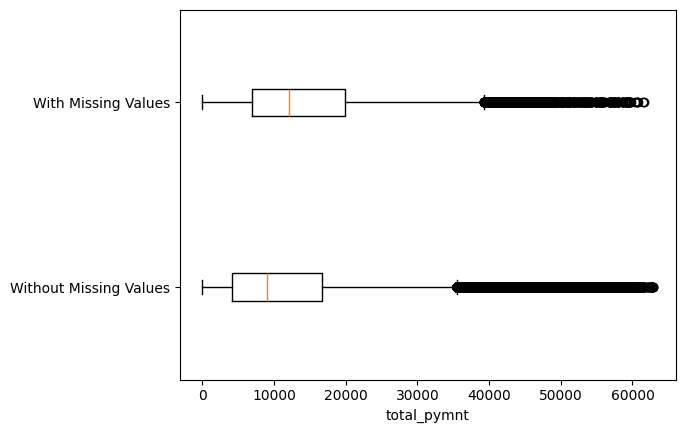

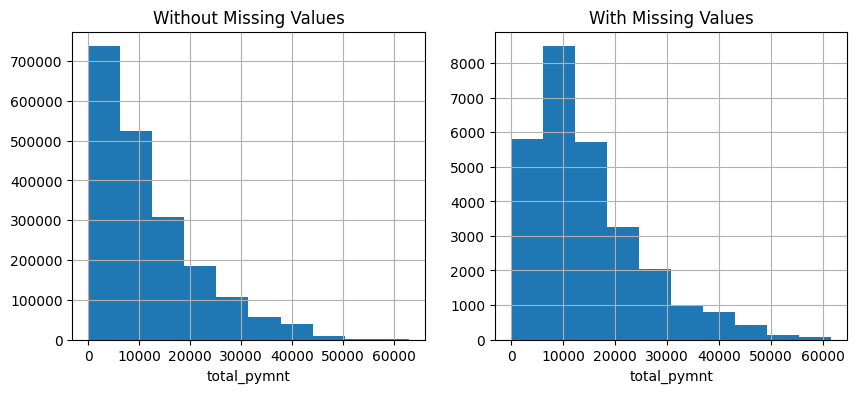

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_sats:


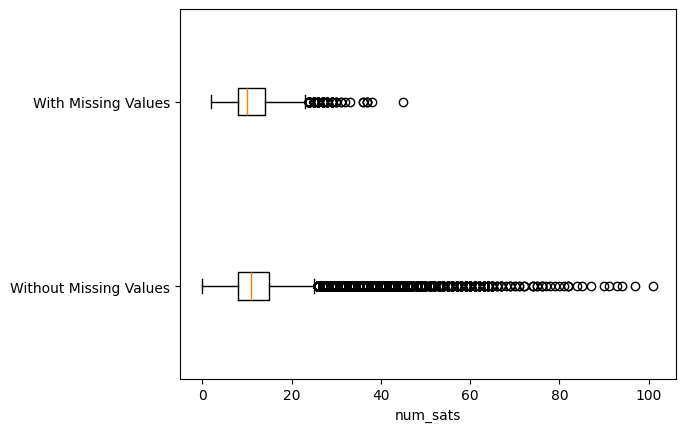

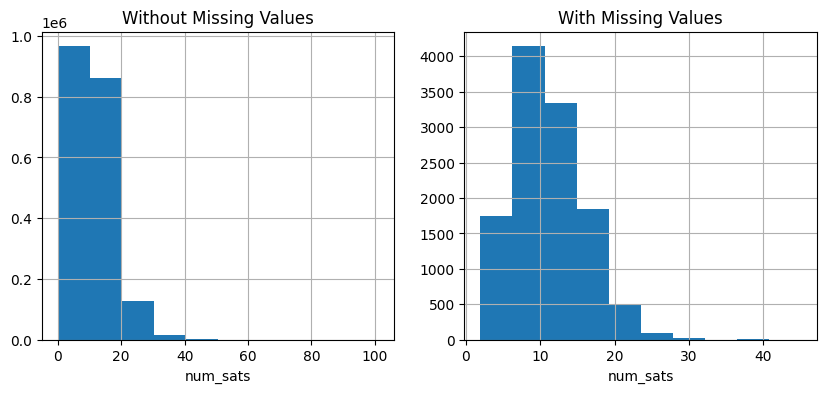

p-value of t-test: 8.492030441144883e-27
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_rec_prncp:


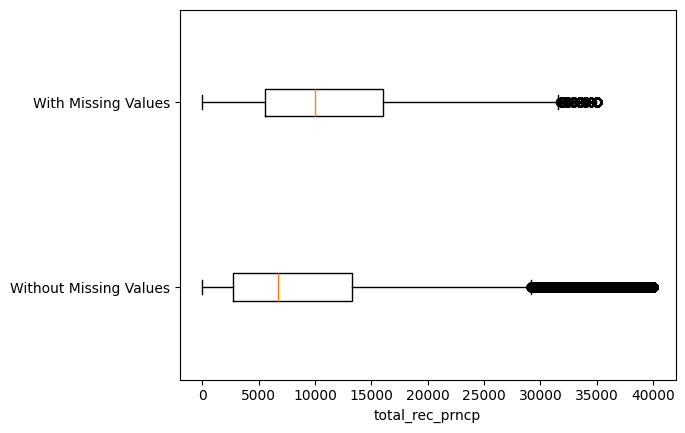

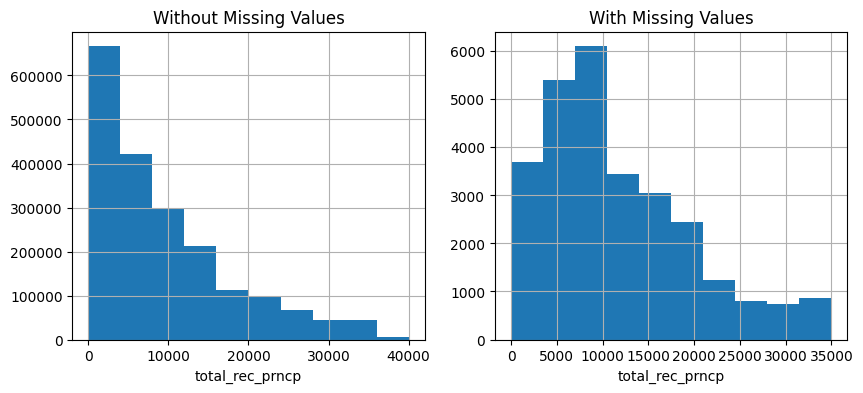

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for num_rev_tl_bal_gt_0:


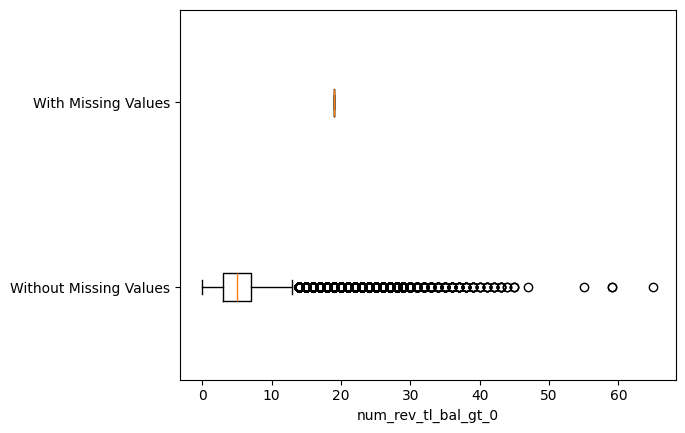

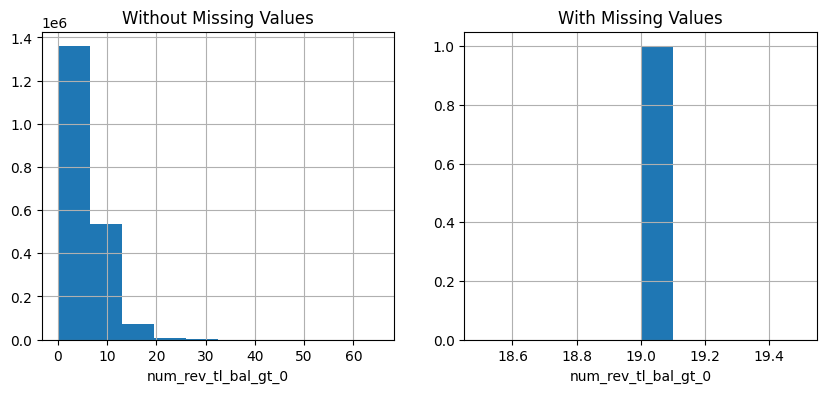

p-value of t-test: 5.041860564112922e-05
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_hi_cred_lim:


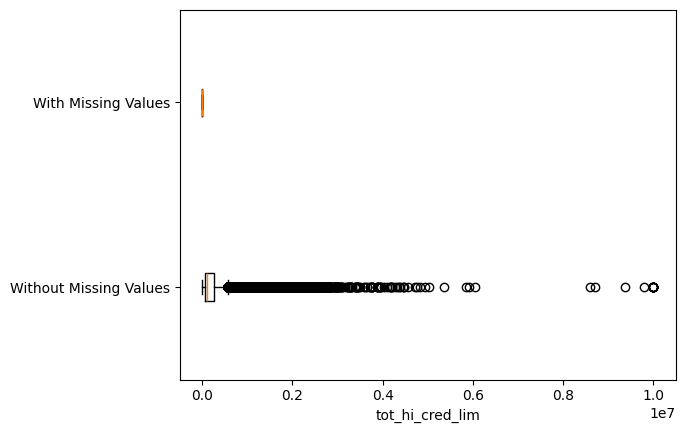

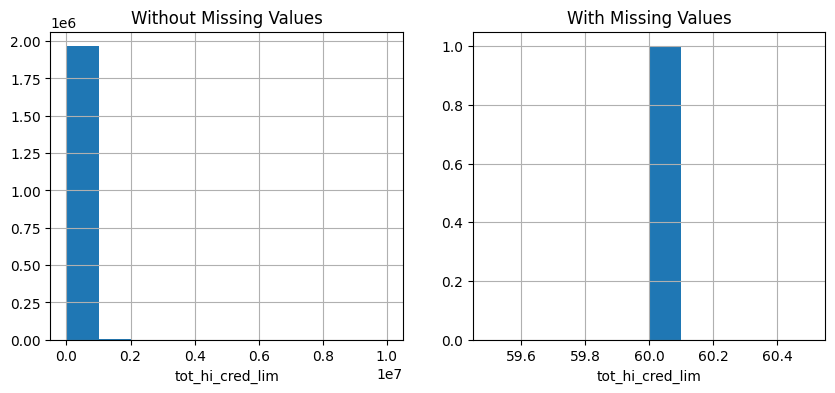

p-value of t-test: 0.32650460016176464
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for tot_cur_bal:


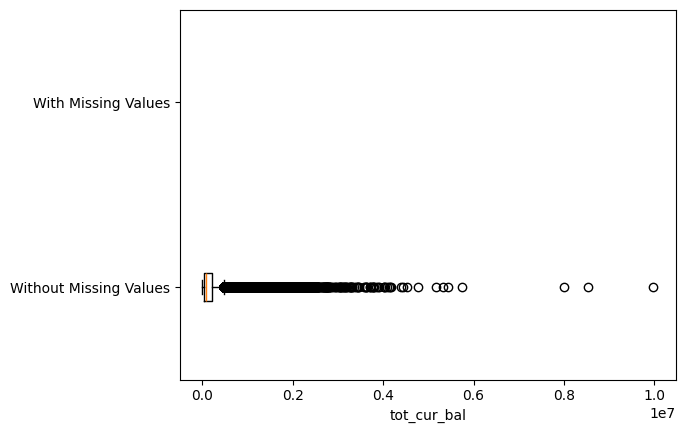

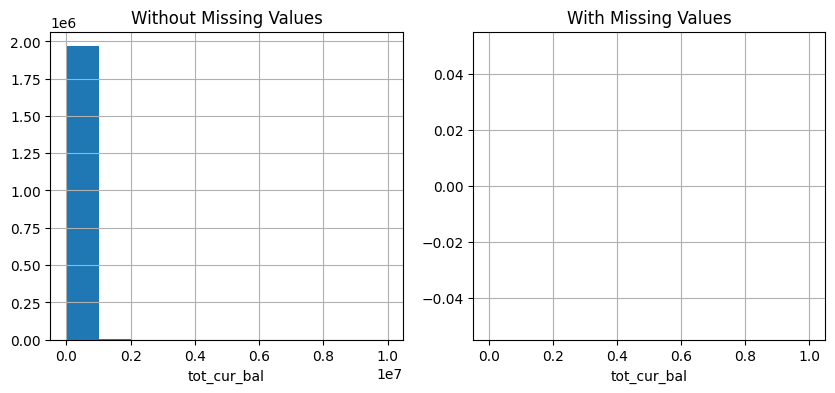

/usr/local/lib/python3.11/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


p-value of t-test: nan
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for open_acc:


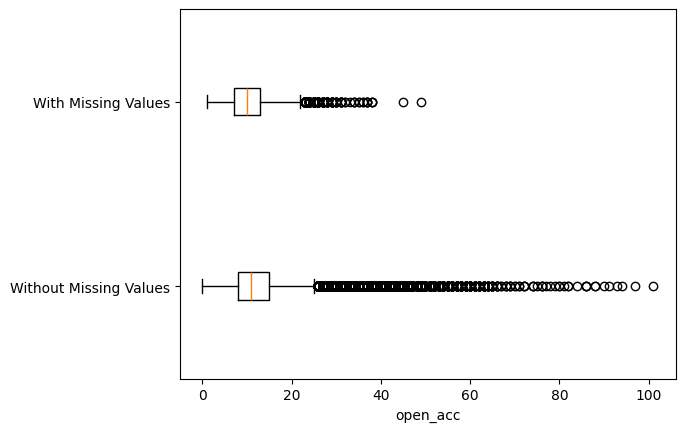

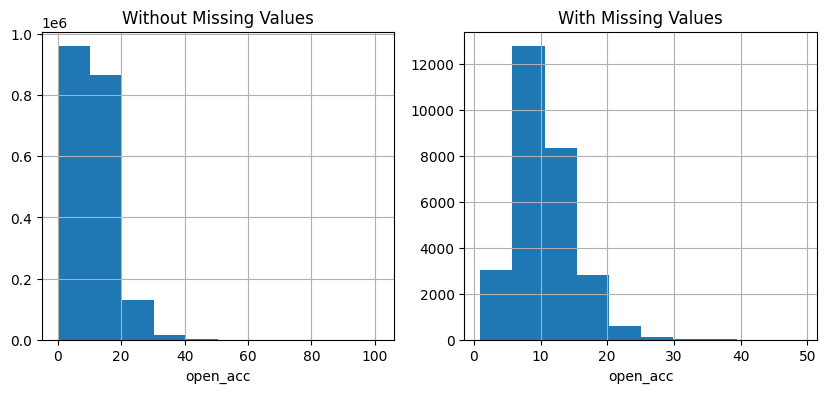

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for last_pymnt_amnt:


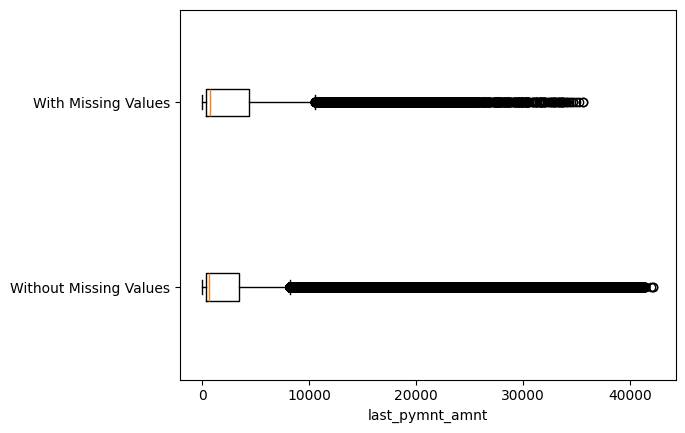

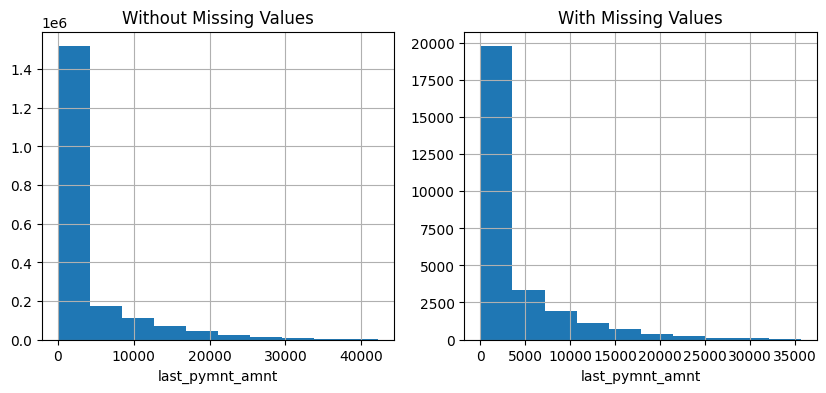

p-value of t-test: 0.2213493758607108
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_bal_il:


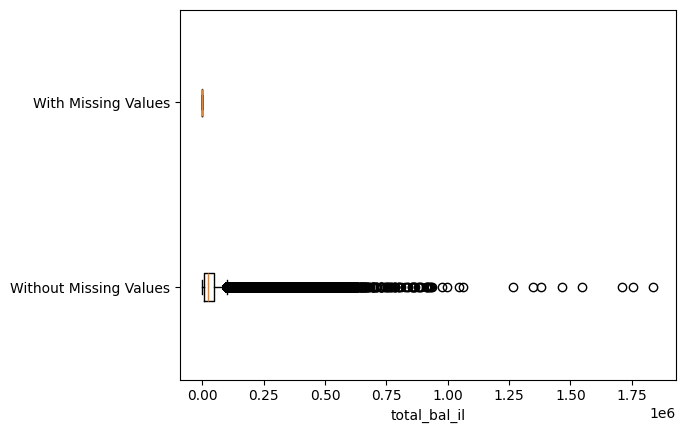

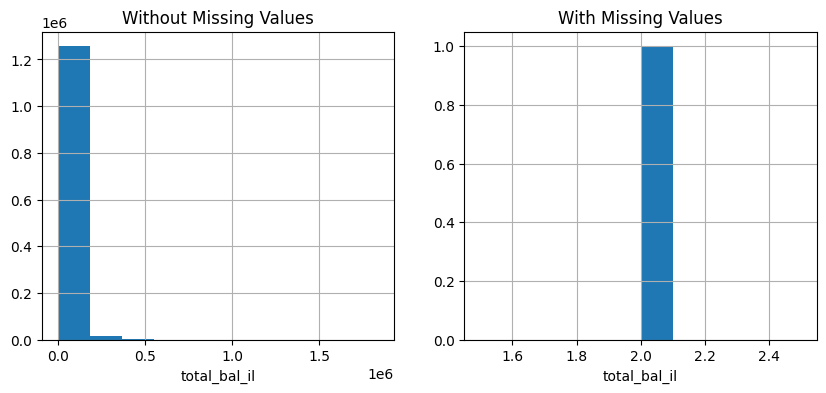

p-value of t-test: 0.4200110522115339
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_il_high_credit_limit:


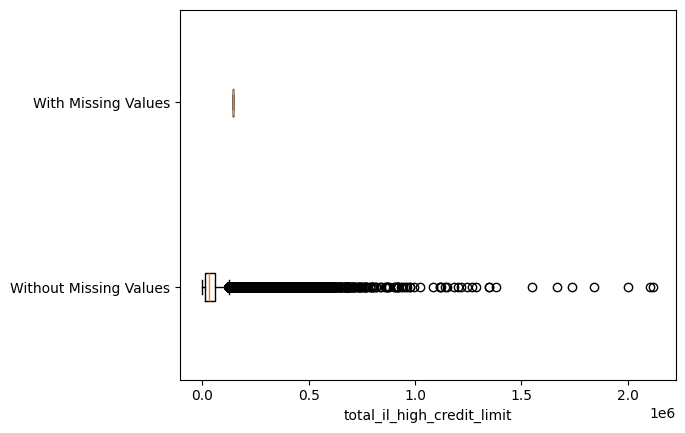

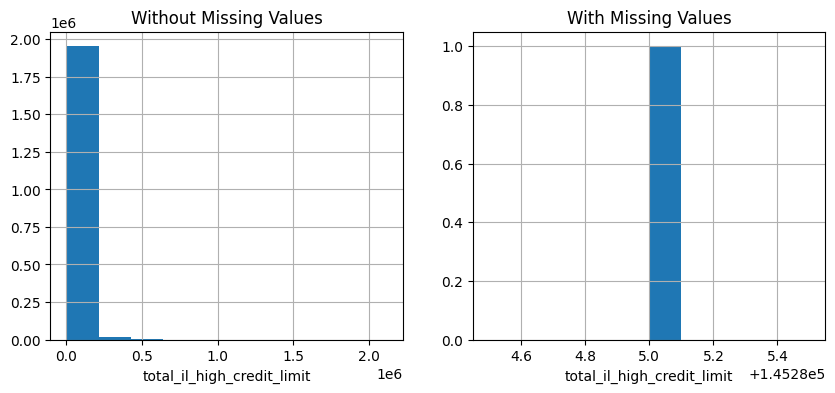

p-value of t-test: 0.024793926060208003
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for installment:


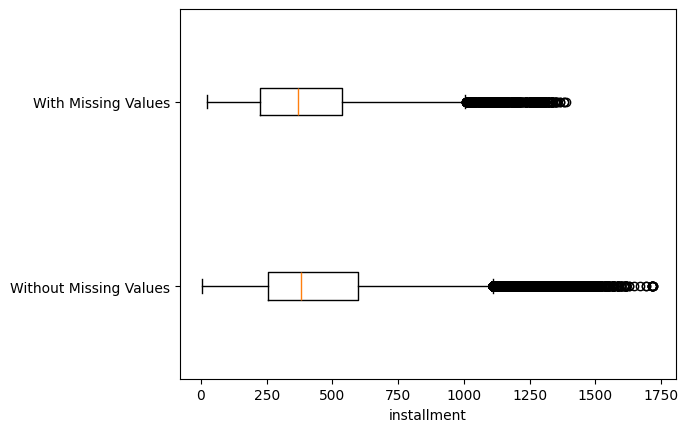

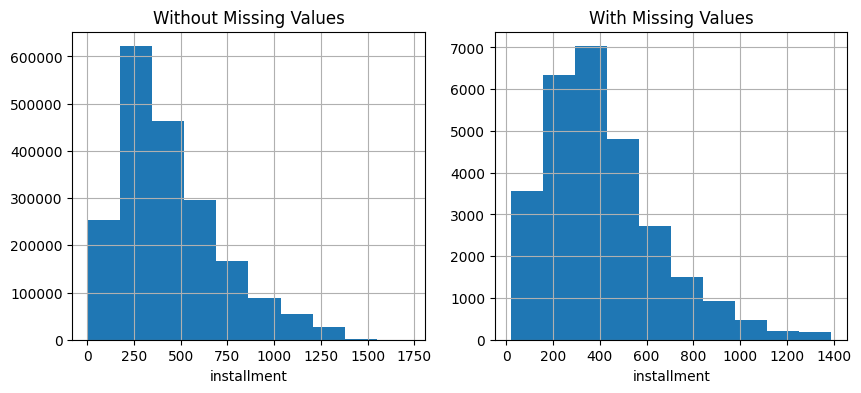

p-value of t-test: 9.871948154973354e-116
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for total_bal_ex_mort:


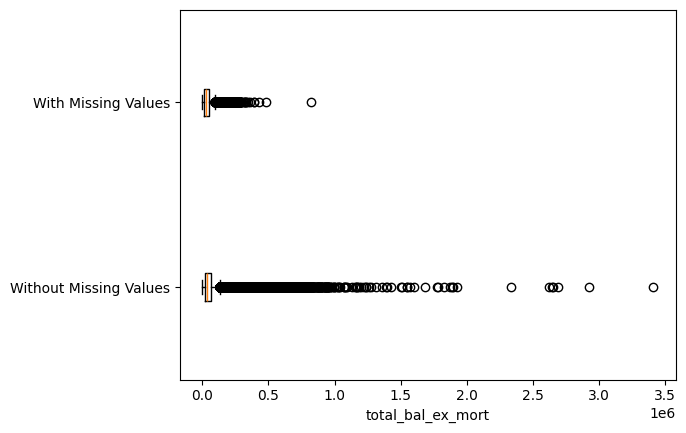

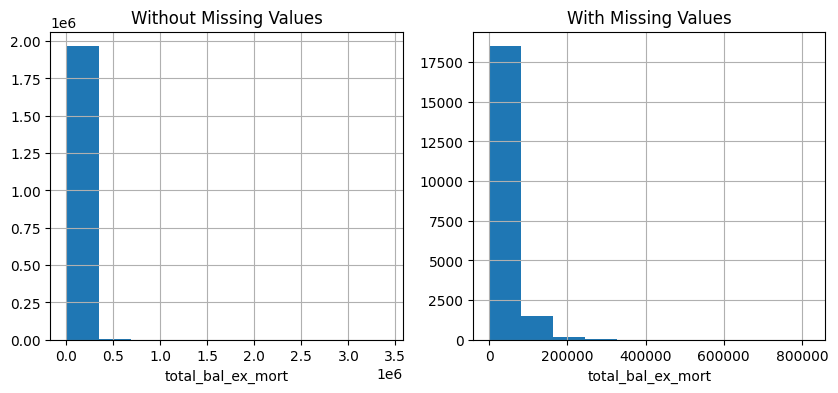

p-value of t-test: 3.9517326226550176e-296
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for revol_util:


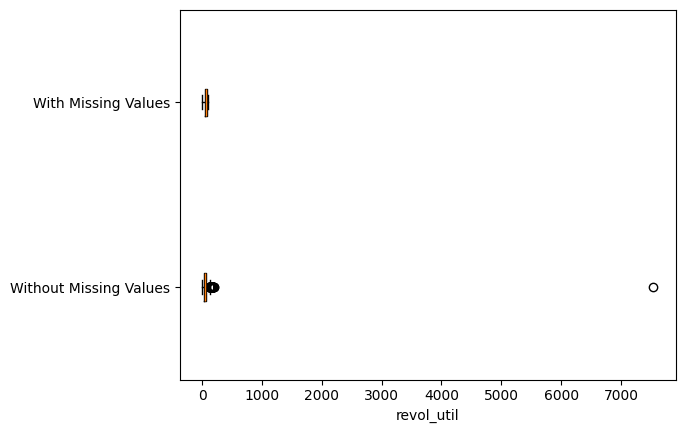

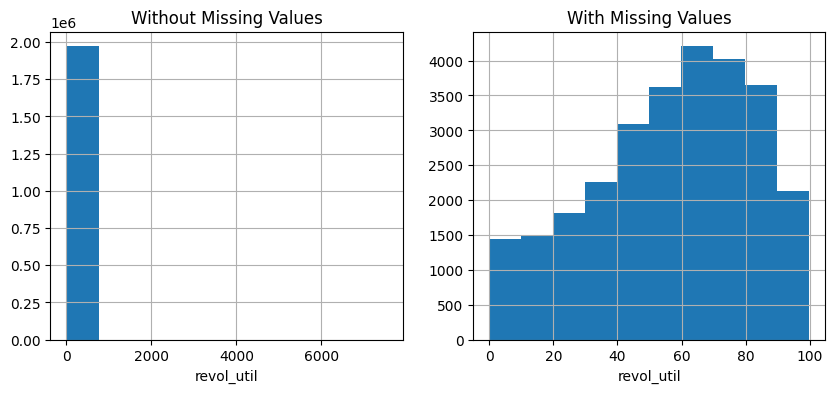

p-value of t-test: 0.0
- - - - - - - - - - - - divider - - - - - - - - - - - 
Diagnosis Analysis of Missing Values for bc_util:


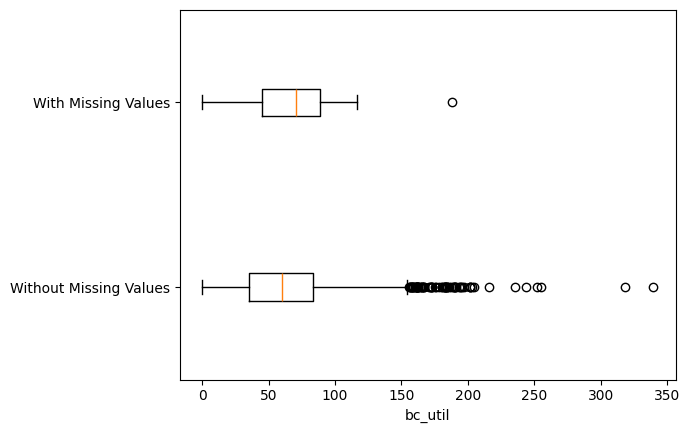

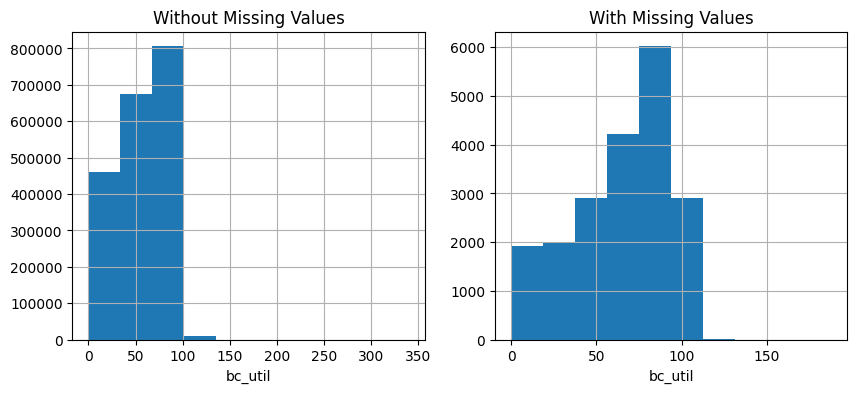

p-value of t-test: 6.298510954338201e-223
- - - - - - - - - - - - divider - - - - - - - - - - - 


In [21]:
numerical_attributes = ['num_sats','loan_amnt','total_pymnt','num_sats','total_rec_prncp','num_rev_tl_bal_gt_0','tot_hi_cred_lim','tot_cur_bal','open_acc','last_pymnt_amnt','total_bal_il','total_il_high_credit_limit','installment','total_bal_ex_mort','revol_util','bc_util']

BM_MV = df_pd['num_actv_rev_tl'].isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(df_pd,att,BM_MV)
    print('- - - - - - - - - - - - divider - - - - - - - - - - - ')

Despuès de hacer varias pruebas, considero que la imputaciòn de datos se puede hacer mediante la mediana, ya que esta no moverà tanto el resultado de los datos ni el accuracy que estos lleguen a tener.

In [30]:
fig, axes = plt.subplots(len(cat_cols), len(num_cols), figsize=(70,35))

for i, col in enumerate(cat_cols):
    for j, col2 in enumerate(num_cols):
        sns.boxplot(x=col, y=col2, data=df_pd, ax=axes[i][j], hue=col)
        axes[i][j].set_title(f'{col} vs {col2}')
        axes[i][j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Se procede a realizar la imputación de datos, decido no hacer aún ningún tipo de escalación, ya que la actividad no lo solicita.

In [22]:
from pyspark.sql.functions import median

# Definir las columnas a incluir
columns_to_include = [col for col in dfML.columns if col not in ['home_ownership', 'emp_length', 'grade', 'funded_amt', 'installment']]

# Calcular las medianas en un solo paso
df_median = dfML.groupby('home_ownership', 'emp_length', 'grade').agg(
    *[median(col).alias(f"median_{col}") for col in columns_to_include]
)

df_median.show(4)


+--------------+----------+-----+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+------------------+------------------+------------------+
|home_ownership|emp_length|grade|median_out_prncp|median_loan_amnt|median_total_pymnt|median_num_sats|median_total_rec_prncp|median_num_rev_tl_bal_gt_0|median_num_actv_rev_tl|median_tot_hi_cred_lim|median_tot_cur_bal|median_open_acc|median_last_pymnt_amnt|median_total_bal_il|median_total_il_high_credit_limit|median_total_bal_ex_mort| median_revol_util|    median_bc_util|median_funded_amnt|
+--------------+----------+-----+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+----------------

In [23]:
dfML_Med = dfML.join(df_median, on=['home_ownership', 'emp_length', 'grade'], how='left')
dfML_Med.select('home_ownership','emp_length','grade', 'total_bal_il', 'median_total_bal_il' ).show()

+--------------+----------+-----+------------+-------------------+
|home_ownership|emp_length|grade|total_bal_il|median_total_bal_il|
+--------------+----------+-----+------------+-------------------+
|      MORTGAGE|    1 year|    A|        NULL|            27823.5|
|      MORTGAGE|    1 year|    E|        NULL|            34283.0|
|      MORTGAGE| 10+ years|    A|     69959.0|            23906.0|
|      MORTGAGE| 10+ years|    A|      4378.0|            23906.0|
|      MORTGAGE| 10+ years|    A|        NULL|            23906.0|
|      MORTGAGE| 10+ years|    A|        NULL|            23906.0|
|      MORTGAGE| 10+ years|    A|        NULL|            23906.0|
|      MORTGAGE| 10+ years|    C|     28845.0|            28167.5|
|      MORTGAGE| 10+ years|    C|    131524.0|            28167.5|
|      MORTGAGE| 10+ years|    C|      7133.0|            28167.5|
|      MORTGAGE| 10+ years|    C|         0.0|            28167.5|
|      MORTGAGE| 10+ years|    C|     35369.0|            2816

In [24]:
from pyspark.sql.functions import when, col

# Iterar sobre las columnas de interés e imputar valores nulos con su correspondiente mediana
for column in columns_to_include:
    dfML_Med = dfML_Med.withColumn(
        column,
        when(col(column).isNull(), col(f"median_{column}")).otherwise(col(column))
    )


dfML_Med.select('home_ownership','emp_length','grade', 'total_bal_il', 'median_total_bal_il' ).show()

+--------------+----------+-----+------------+-------------------+
|home_ownership|emp_length|grade|total_bal_il|median_total_bal_il|
+--------------+----------+-----+------------+-------------------+
|      MORTGAGE|    1 year|    A|     27823.5|            27823.5|
|      MORTGAGE|    1 year|    E|     34283.0|            34283.0|
|      MORTGAGE| 10+ years|    A|     69959.0|            23906.0|
|      MORTGAGE| 10+ years|    A|      4378.0|            23906.0|
|      MORTGAGE| 10+ years|    A|     23906.0|            23906.0|
|      MORTGAGE| 10+ years|    A|     23906.0|            23906.0|
|      MORTGAGE| 10+ years|    A|     23906.0|            23906.0|
|      MORTGAGE| 10+ years|    C|     28845.0|            28167.5|
|      MORTGAGE| 10+ years|    C|    131524.0|            28167.5|
|      MORTGAGE| 10+ years|    C|      7133.0|            28167.5|
|      MORTGAGE| 10+ years|    C|         0.0|            28167.5|
|      MORTGAGE| 10+ years|    C|     35369.0|            2816

In [25]:
print('REGISTROS NULOS POSTERIORES A LA IMPUTACIÓN')
for column in columns_to_include:
    print(f' {column}: {dfML_Med.filter(col(column).isNull()).count()}')

REGISTROS NULOS POSTERIORES A LA IMPUTACIÓN
 out_prncp: 1
 loan_amnt: 0
 total_pymnt: 0
 num_sats: 85
 total_rec_prncp: 0
 num_rev_tl_bal_gt_0: 85
 num_actv_rev_tl: 85
 tot_hi_cred_lim: 85
 tot_cur_bal: 85
 open_acc: 4
 last_pymnt_amnt: 1
 total_bal_il: 224
 total_il_high_credit_limit: 85
 total_bal_ex_mort: 82
 revol_util: 4
 bc_util: 87
 funded_amnt: 0


In [26]:
#conteo previo a hacer el drop por campos nulos
dfML_Med.count()

2260668

In [27]:
dfML_Med = dfML_Med.na.drop()

In [28]:
#conteo posterior a hacer el drop por campos nulos
dfML_Med.count()

2260442

# 4. Preparación del conjunto de entranamiento


Decidí sólo justificar la muestra, debido a que se han imputado valores en los datos nulos y sólo se han eliminado 226 filas que no se logró imputar.

Con relación a las combinaciónes, considero de mayor relevancia sólo dividir el dataset en entrenamiento y prueba, lo anterior a que los datos de entrenamiento son suficientes para poder detectar patrones. Las combinaciones emanan de tres columnas que es **tipo de vivienda, tiempo de empleo y calificación crediticia**.

Lo anterior debido a que al hacer un análisis de correlación entre las varibles, estás son las que más tienen entre sí, igualmente se realizó un análisis multivariante con boxplots y el resultado de las variables anteriores son los más relevantes.

Por úlitmo, decidí enfocar la actividad en pronosticar la cantidad máxima de préstamo que se le puede hacer a una persona en relación al modelo de aprendizaje supervisado. Mientras que para el no supervisado, decidí poder aplicarlo en la calificación crediticia, mediante vecinos más cercanos.

In [29]:
# Contar el total de filas
pob = dfML_Med.count()

# Agrupar y calcular la proporción de cada combinación
combinación = dfML_Med.groupBy("home_ownership", "emp_length", "grade").count() \
    .withColumnRenamed("count", "count_combinación") \
    .withColumn("porcentaje_combinación", col("count_combinación") / pob) \
    .orderBy("count_combinación", ascending =False)

# Mostrar resultados
print("Combinación de variables: ", combinación.count())
combinación.show(truncate=False)

Combinación de variables:  324
+--------------+----------+-----+-----------------+----------------------+
|home_ownership|emp_length|grade|count_combinación|porcentaje_combinación|
+--------------+----------+-----+-----------------+----------------------+
|MORTGAGE      |10+ years |B    |133999           |0.05927999922139122   |
|MORTGAGE      |10+ years |C    |123865           |0.054796805226588426  |
|MORTGAGE      |10+ years |A    |98660            |0.04364633111577293   |
|RENT          |10+ years |C    |64505            |0.028536454374852353  |
|RENT          |10+ years |B    |60938            |0.026958444410429466  |
|MORTGAGE      |10+ years |D    |58545            |0.02589980189715109   |
|RENT          |10+ years |D    |33917            |0.015004587598354657  |
|RENT          |10+ years |A    |31510            |0.013939751606101815  |
|RENT          |2 years   |C    |31156            |0.013783145066318888  |
|RENT          |2 years   |B    |30231            |0.0133739330626488

# 5. Construcción de modelos de aprendizaje supervisado y no supervisado

In [34]:
from pyspark.ml.feature import StringIndexer

df_ind= StringIndexer(inputCols=['home_ownership', 'emp_length', 'grade'],
                      outputCols=['home_ownership_ind', 'emp_length_ind', 'grade_ind']).fit(dfML_Med).transform(dfML_Med)

df_ind.show()


+--------------+----------+-----+---------+---------+----------------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+-----------+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+-----------------+--------------+------------------+------------------+--------------+---------+
|home_ownership|emp_length|grade|out_prncp|loan_amnt|     total_pymnt|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|funded_amnt|median_out_prncp|median_loan_am

In [35]:
df_ind.columns

['home_ownership',
 'emp_length',
 'grade',
 'out_prncp',
 'loan_amnt',
 'total_pymnt',
 'num_sats',
 'total_rec_prncp',
 'num_rev_tl_bal_gt_0',
 'num_actv_rev_tl',
 'tot_hi_cred_lim',
 'tot_cur_bal',
 'open_acc',
 'last_pymnt_amnt',
 'total_bal_il',
 'total_il_high_credit_limit',
 'installment',
 'total_bal_ex_mort',
 'revol_util',
 'bc_util',
 'funded_amnt',
 'median_out_prncp',
 'median_loan_amnt',
 'median_total_pymnt',
 'median_num_sats',
 'median_total_rec_prncp',
 'median_num_rev_tl_bal_gt_0',
 'median_num_actv_rev_tl',
 'median_tot_hi_cred_lim',
 'median_tot_cur_bal',
 'median_open_acc',
 'median_last_pymnt_amnt',
 'median_total_bal_il',
 'median_total_il_high_credit_limit',
 'median_total_bal_ex_mort',
 'median_revol_util',
 'median_bc_util',
 'median_funded_amnt',
 'home_ownership_ind',
 'emp_length_ind',
 'grade_ind']

In [40]:
from pyspark.ml.linalg import Vector
from pyspark.ml.feature import VectorAssembler

assembler_lr = VectorAssembler(
    inputCols=[
        'out_prncp',
        'total_pymnt',
        'num_sats',
        'total_rec_prncp',
        'num_rev_tl_bal_gt_0',
        'num_actv_rev_tl',
        'tot_hi_cred_lim',
        'tot_cur_bal',
        'open_acc',
        'last_pymnt_amnt',
        'total_bal_il',
        'total_il_high_credit_limit',
        'installment',
        'total_bal_ex_mort',
        'revol_util',
        'bc_util',
        'home_ownership_ind',
        'emp_length_ind',
        'grade_ind'
    ],
    outputCol="features"
)

df_sup= assembler_lr.transform(df_ind)

df_sup.select('out_prncp',
        'total_pymnt',
        'num_sats',
        'total_rec_prncp',
        'num_rev_tl_bal_gt_0',
        'num_actv_rev_tl',
        'tot_hi_cred_lim',
        'tot_cur_bal',
        'open_acc',
        'last_pymnt_amnt',
        'total_bal_il',
        'total_il_high_credit_limit',
        'installment',
        'total_bal_ex_mort',
        'revol_util',
        'bc_util',
        'home_ownership_ind',
        'emp_length_ind',
        'grade_ind',
        'features'
        ).show(4)

+--------------+----------+-----+---------+---------+-----------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+-----------+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+-----------------+--------------+------------------+------------------+--------------+---------+--------------------+
|home_ownership|emp_length|grade|out_prncp|loan_amnt|total_pymnt|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|funded_amnt|median_out_prncp|med

In [39]:
assembler_Knn= VectorAssembler (
  inputCols=[
    'out_prncp',
    'total_pymnt',
    'num_sats',
    'total_rec_prncp',
    'num_rev_tl_bal_gt_0',
    'num_actv_rev_tl',
    'tot_hi_cred_lim',
    'tot_cur_bal',
    'open_acc',
    'last_pymnt_amnt',
    'total_bal_il',
    'total_il_high_credit_limit',
    'installment',
    'revol_util',
    'total_bal_ex_mort',
    'bc_util',
    'loan_amnt',
    'home_ownership_ind',
    'emp_length_ind'
  ],
  outputCol="features"
)

df_unsup= assembler_Knn.transform(df_ind)

df_unsup.select(
    'out_prncp',
    'total_pymnt',
    'num_sats',
    'total_rec_prncp',
    'num_rev_tl_bal_gt_0',
    'num_actv_rev_tl',
    'tot_hi_cred_lim',
    'tot_cur_bal',
    'open_acc',
    'last_pymnt_amnt',
    'total_bal_il',
    'total_il_high_credit_limit',
    'installment',
    'revol_util',
    'total_bal_ex_mort',
    'bc_util',
    'home_ownership_ind',
    'emp_length_ind',
    'features'
).show(4)


+--------------+----------+-----+---------+---------+-----------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+-----------+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+-----------------+--------------+------------------+------------------+--------------+---------+--------------------+
|home_ownership|emp_length|grade|out_prncp|loan_amnt|total_pymnt|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|funded_amnt|median_out_prncp|med

In [41]:
from pyspark.sql.functions import rand

df_shf_sup = df_sup.orderBy(rand())
df_shf_unsup = df_unsup.orderBy(rand())

df_shf_sup.show(4)
df_shf_unsup.show(4)

+--------------+----------+-----+---------+---------+-----------+--------+---------------+-------------------+---------------+---------------+-----------+--------+---------------+------------+--------------------------+-----------+-----------------+----------+-------+-----------+----------------+----------------+------------------+---------------+----------------------+--------------------------+----------------------+----------------------+------------------+---------------+----------------------+-------------------+---------------------------------+------------------------+-----------------+--------------+------------------+------------------+--------------+---------+--------------------+
|home_ownership|emp_length|grade|out_prncp|loan_amnt|total_pymnt|num_sats|total_rec_prncp|num_rev_tl_bal_gt_0|num_actv_rev_tl|tot_hi_cred_lim|tot_cur_bal|open_acc|last_pymnt_amnt|total_bal_il|total_il_high_credit_limit|installment|total_bal_ex_mort|revol_util|bc_util|funded_amnt|median_out_prncp|med

In [42]:
fd_sup= df_shf_sup.select('funded_amnt','features')
fd_sup.show(4)

+-----------+--------------------+
|funded_amnt|            features|
+-----------+--------------------+
|     8000.0|[6843.18,1572.61,...|
|     9600.0|[0.0,10254.44,11....|
|    25000.0|[16267.32,13671.4...|
|    20000.0|[0.0,28891.95,17....|
+-----------+--------------------+
only showing top 4 rows



In [43]:
fd_unsup= df_shf_unsup.select('grade','features')
fd_unsup.show(4)

+-----+--------------------+
|grade|            features|
+-----+--------------------+
|    B|[0.0,17455.367840...|
|    C|[0.0,43339.259458...|
|    A|[0.0,2089.5680462...|
|    D|[0.0,22188.614748...|
+-----+--------------------+
only showing top 4 rows



In [44]:
train_data_sup, test_data_sup = fd_sup.randomSplit([0.7, 0.3], seed=42)
train_data_unsup, test_data_unsup = fd_unsup.randomSplit([0.7, 0.3], seed=42)

print('data supervisado')
print(train_data_sup.count())
print(test_data_sup.count())
train_data_sup.describe().show()
test_data_sup.describe().show()
print('data no supervisado')
print(train_data_unsup.count())
print(test_data_unsup.count())
train_data_unsup.describe().show()
test_data_unsup.describe().show()

data supervisado
1582865
677500
+-------+-----------------+
|summary|      funded_amnt|
+-------+-----------------+
|  count|          1582901|
|   mean|15045.62294167481|
| stddev|9191.778943152738|
|    min|            500.0|
|    max|          40000.0|
+-------+-----------------+

+-------+------------------+
|summary|       funded_amnt|
+-------+------------------+
|  count|            677459|
|   mean|15031.226908196659|
| stddev| 9178.644700808813|
|    min|             500.0|
|    max|           40000.0|
+-------+------------------+

data no supervisado
1582849
677519
+-------+-------+
|summary|  grade|
+-------+-------+
|  count|1582969|
|   mean|   NULL|
| stddev|   NULL|
|    min|      A|
|    max|      G|
+-------+-------+

+-------+------+
|summary| grade|
+-------+------+
|  count|677537|
|   mean|  NULL|
| stddev|  NULL|
|    min|     A|
|    max|     G|
+-------+------+



# Supervisado: target Funded Amount

In [46]:
from pyspark.ml.regression import LinearRegression

In [47]:
fa_lr= LinearRegression(featuresCol='features', labelCol='funded_amnt')
fa_lr_model= fa_lr.fit(train_data_sup)

In [48]:
metrics_lr=fa_lr_model.evaluate(train_data_sup)

In [49]:
print('RMSE: ', metrics_lr.rootMeanSquaredError)
print('R2: ', metrics_lr.r2)
print('MSE: ', metrics_lr.meanSquaredError)
print('MAE: ', metrics_lr.meanAbsoluteError)

RMSE:  2115.6047776115356
R2:  0.9470178492816796
MSE:  4475783.575052756
MAE:  1454.8939642326038


In [57]:
data_test = test_data_sup.select('features')
predict_data= fa_lr_model.transform(data_test)
predict_data.show(truncate=False)

+----------------------------------------------------------------------------------------------------------------------+------------------+
|features                                                                                                              |prediction        |
+----------------------------------------------------------------------------------------------------------------------+------------------+
|[0.0,565.0251576794,10.0,500.0,4.0,4.0,70079.0,36024.5,4.0,33.16,19826.0,32153.0,15.69,34537.0,0.0,40.2,1.0,2.0,2.0]  |897.6117620515774 |
|[0.0,899.5595849663,10.0,700.0,4.0,4.0,60820.5,45752.0,14.0,26.77,35249.0,36686.5,24.99,43704.0,22.6,73.5,1.0,2.0,6.0]|-570.0147643865362|
|[0.0,901.025438435702,10.0,800.0,4.0,4.0,57512.5,34973.0,5.0,412.96,21537.0,30482.5,25.8,33636.0,0.0,57.8,1.0,2.0,0.0]|1680.4820321740885|
|[0.0,489.65,10.0,328.14,5.0,5.0,53556.0,37027.0,5.0,30.93,24566.0,31429.0,30.93,36247.5,7.3,71.1,1.0,1.0,4.0]         |256.46769376806105|
|(19,[0,1,2,3,6,8,9,

# No Supervisado: Target GRADE

In [52]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [53]:
kmeans = KMeans(featuresCol='features',k=7, seed=42)

In [54]:
fa_knn_model= kmeans.fit(train_data_unsup)

In [55]:
predict_unsup= fa_knn_model.transform(test_data_unsup)
predict_unsup.show()

+-----+--------------------+----------+
|grade|            features|prediction|
+-----+--------------------+----------+
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         0|
|    A|(18,[0,1,2,3,6,7,...|         4|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         0|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,7,...|         3|
|    A|(18,[0,1,2,3,6,7,...|         4|
|    A|(18,[0,1,2,3,6,7,...|         2|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
|    A|(18,[0,1,2,3,6,8,...|         0|
+-----+--------------------+----------+
only showing top 20 rows



In [56]:
predict_unsup.groupBy('grade','prediction').count().show()

+-----+----------+------+
|grade|prediction| count|
+-----+----------+------+
|    C|         6|   193|
|    E|         4|  5160|
|    G|         0|  1961|
|    B|         5|  4097|
|    F|         3|   655|
|    C|         3| 11728|
|    B|         0|101113|
|    G|         2|   927|
|    G|         1|    41|
|    F|         2|  3052|
|    F|         6|    10|
|    D|         0| 54916|
|    G|         5|    99|
|    A|         3| 12983|
|    A|         5|  2800|
|    E|         2|  9414|
|    B|         6|   238|
|    D|         6|    86|
|    E|         6|    35|
|    G|         4|   420|
+-----+----------+------+
only showing top 20 rows

